# RLI Assignment 22.00: Mountain Car

## Setup & Dependencies


In [1]:
# Uncomment to install dependencies (all should be present in the project venv)
# !pip install gymnasium stable-baselines3 torch matplotlib numpy pandas seaborn tensorboard

# Library versions used:
# gymnasium==1.2.3, stable-baselines3==2.8.0, torch==2.10.0, numpy==2.2.6


In [2]:
import sys
sys.path.insert(0, '.')

import mclib as mc

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns
import time, random, warnings
warnings.filterwarnings('ignore')
import os
import gymnasium as gym
import torch
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

print("Setup complete.")


Setup complete.


## 1. Environment Analysis

### 1.1 The Mountain Car Problem

In [3]:
# Explore both environment versions
env_disc = gym.make('MountainCar-v0')
env_cont = gym.make('MountainCarContinuous-v0')

print("DISCRETE: MountainCar-v0")
print(f"Action space: {env_disc.action_space}")
print(f"Observation space: {env_disc.observation_space}")
print(f"Obs low: {env_disc.observation_space.low}")
print(f"Obs high: {env_disc.observation_space.high}")

print("\nCONTINUOUS: MountainCarContinuous-v0")
print(f"Action space: {env_cont.action_space}")
print(f"Observation space: {env_cont.observation_space}")

env_disc.close()
env_cont.close()


DISCRETE: MountainCar-v0
Action space: Discrete(3)
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Obs low: [-1.2  -0.07]
Obs high: [0.6  0.07]

CONTINUOUS: MountainCarContinuous-v0
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)


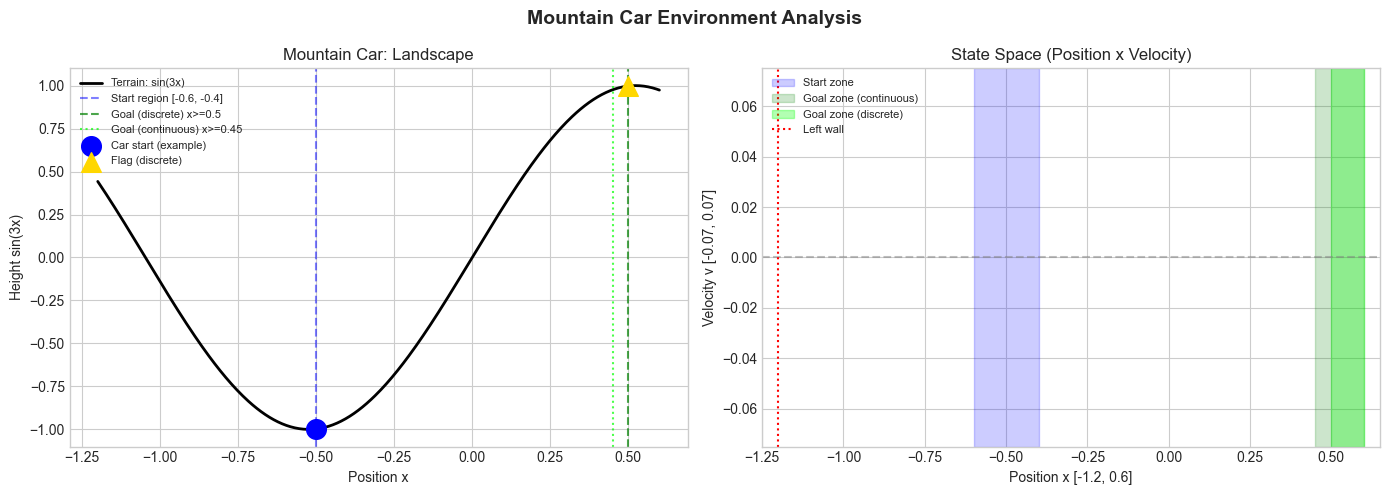

In [4]:

# Visualize the landscape and phase portrait concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Mountain Car landscape
x = np.linspace(-1.2, 0.6, 400)
y = np.sin(3 * x)  # height profile

ax = axes[0]
ax.plot(x, y, 'k-', linewidth=2, label='Terrain: sin(3x)')
ax.axvline(-0.5, color='blue', linestyle='--', alpha=0.5, label='Start region [-0.6, -0.4]')
ax.axvline(0.5,  color='green', linestyle='--', alpha=0.7, label='Goal (discrete) x>=0.5')
ax.axvline(0.45, color='lime',  linestyle=':',  alpha=0.7, label='Goal (continuous) x>=0.45')
ax.scatter([-0.5], [np.sin(-1.5)], s=200, c='blue',  zorder=5, label='Car start (example)')
ax.scatter([0.5],  [np.sin(1.5)],  s=200, c='gold', marker='^', zorder=5, label='Flag (discrete)')
ax.set_xlabel('Position x')
ax.set_ylabel('Height sin(3x)')
ax.set_title('Mountain Car: Landscape')
ax.legend(fontsize=8, loc='upper left')

# Right: State space boundaries
ax2 = axes[1]
ax2.set_xlim(-1.25, 0.65)
ax2.set_ylim(-0.075, 0.075)

# Shade the starting zone
ax2.axvspan(-0.6, -0.4, alpha=0.2, color='blue', label='Start zone')
ax2.axvspan(0.45, 0.6, alpha=0.2, color='green', label='Goal zone (continuous)')
ax2.axvspan(0.5, 0.6, alpha=0.3, color='lime', label='Goal zone (discrete)')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(-1.2, color='red', linestyle=':', label='Left wall')
ax2.set_xlabel('Position x [-1.2, 0.6]')
ax2.set_ylabel('Velocity v [-0.07, 0.07]')
ax2.set_title('State Space (Position x Velocity)')
ax2.legend(fontsize=8)

plt.suptitle('Mountain Car Environment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Scenario 1: Discrete Minimum Steps

**Design Choices -- Scenario 1: Discrete, Minimize Steps**

**State representation:** Raw 2D observation (position, velocity). Tabular agents (Q-Learning, SARSA) discretize into a 40x40 grid. DQN uses the raw continuous state as input to the neural network.

**Rewards:** Two designs compared:
- Default: -1 per timestep (gymnasium standard). Already aligned with the minimize-steps objective.
- Energy-shaped: default reward + phi(s') - phi(s) where phi(s) = pos + 0.5 * vel^2. Potential-based shaping (Ng et al. 1999), probably preserves the optimal policy but provides a denser learning signal. Applied to Q-Learning as a controlled comparison. Evaluation always uses the default reward so metrics are comparable.

**Algorithms:** Three models across two families:
- Q-Learning (tabular, off-policy): Bellman optimality update, max over next actions
- SARSA (tabular, on-policy): same structure but updates using the action actually taken
- DQN (neural, off-policy): 2-layer MLP approximating Q-values, experience replay + target network

**Training strategy:**
- Q-Learning / SARSA: 15,000 episodes, epsilon-greedy with multiplicative decay (x0.9997/episode), evaluated every 2,000 episodes
- DQN: 200,000 steps, exponential epsilon decay (half-life ~8,000 steps), replay buffer 50k, evaluated every 20,000 steps

**Custom Wrappers:** None for the 3 main models. EnergyShapingWrapper used for the Q-Learning shaped variant.

**Hyperparameters:**
- Q-Learning & SARSA: n_bins=40, alpha=0.15, gamma=0.99, epsilon: 1.0 to 0.01 (decay=0.9997/ep)
- DQN: lr=1e-3, gamma=0.99, epsilon: 1.0 to 0.01 (decay=8000 steps), buffer=50k, batch=64, target_update=500

**Objective performance vs engineered reward:** Q-Learning is trained under both reward designs and evaluated on the default reward. The shaped variant should converge faster due to the denser gradient while reaching the same final performance, validating that the shaping does not distort the objective.


In [5]:
# Scenario 1 — sanity check: MountainCar-v0 default reward
env = mc.make_s1()
obs, _ = env.reset(seed=0)
print(f"Observation space : {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial obs: {obs}")
obs2, r, term, trunc, _ = env.step(2)
print(f"Default reward for action=2: {r}  (should be -1.0)")
env.close()


Observation space : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial obs: [-0.47260767  0.        ]
Default reward for action=2: -1.0  (should be -1.0)


### Model 1: Tabular Q-Learning (default hyperparameters)

In [6]:
s1_ql_agent = mc.TabularQLearningAgent(n_bins=40, alpha=0.15, gamma=0.99, eps_start=1.0,  eps_end=0.01, eps_decay=0.9997 )

with mc.Testbed('S1/QL_default', log_dir='runs') as tb:
    s1_ql_results = tb.run_tabular(mc.make_s1, s1_ql_agent, n_episodes=15_000, eval_every=2_000,n_eval=50, verbose=True)

s1_ql_rewards = s1_ql_results['rewards']
s1_ql_eval_means = s1_ql_results['eval_means']
s1_ql_eval_stds = s1_ql_results['eval_stds']
s1_ql_eval_eps = s1_ql_results['eval_episodes']
s1_ql_final = s1_ql_results['final']
print(f"\nQL default — mean={np.mean(s1_ql_final):.2f} +/- {np.std(s1_ql_final):.2f} | "
      f"success={np.mean(np.array(s1_ql_final) > -200):.1%}")


[Testbed] 'S1/QL_default' — logs -> runs/S1_QL_default
 Ep   2000 | train_r= -200.0 | eval_mean=-200.00 +/- 0.00 | eps=0.549
 Ep   4000 | train_r= -166.0 | eval_mean=-184.82 +/- 17.09 | eps=0.301
 Ep   6000 | train_r= -200.0 | eval_mean=-186.66 +/- 18.82 | eps=0.165
 Ep   8000 | train_r= -200.0 | eval_mean=-147.38 +/- 13.90 | eps=0.091
 Ep  10000 | train_r= -153.0 | eval_mean=-140.86 +/- 20.63 | eps=0.050
 Ep  12000 | train_r= -141.0 | eval_mean=-136.94 +/- 25.19 | eps=0.027
 Ep  14000 | train_r= -186.0 | eval_mean=-132.96 +/- 26.29 | eps=0.015
[Testbed] Final eval — mean=-145.32 +/- 26.45 | success=100.0%
[Testbed] 'S1/QL_default' closed.

QL default — mean=-145.32 +/- 26.45 | success=100.0%


In [7]:
os.makedirs('models/s1', exist_ok=True)
s1_ql_agent.save('models/s1/ql.npz')

np.save('models/s1/ql_final.npy', s1_ql_results['final'])
np.save('models/s1/ql_rewards.npy', s1_ql_results['rewards'])
np.save('models/s1/ql_eval_means.npy', s1_ql_results['eval_means'])
np.save('models/s1/ql_eval_stds.npy', s1_ql_results['eval_stds'])
np.save('models/s1/ql_eval_eps.npy', s1_ql_results['eval_episodes'])

In [8]:
#visualize the result
# env = gym.make('MountainCar-v0', render_mode='human')
# obs, _ = env.reset(seed=42)
# done = False
# total = 0
# while not done:
#     action = s1_ql_agent.select_action(obs, greedy=True)
#     obs, r, terminated, truncated, _ = env.step(action)
#     total += r
#     done = terminated or truncated
# env.close()
# print(f"Total reward: {total:.1f}")

In [9]:
s1_ql_shaped = mc.TabularQLearningAgent(n_bins=40, alpha=0.15, gamma=0.99,
                                         eps_start=1.0, eps_end=0.01, eps_decay=0.9997)
with mc.Testbed('S1/QL_shaped', log_dir='runs') as tb:
    s1_ql_shaped_results = tb.run_tabular(
        mc.make_s1_shaped, s1_ql_shaped,
        n_episodes=15_000, eval_every=2_000, n_eval=50
    )


[Testbed] 'S1/QL_shaped' — logs -> runs/S1_QL_shaped
 Ep   2000 | train_r= -199.8 | eval_mean=-199.71 +/- 0.61 | eps=0.549
 Ep   4000 | train_r= -200.4 | eval_mean=-174.60 +/- 25.56 | eps=0.301
 Ep   6000 | train_r= -184.0 | eval_mean=-183.37 +/- 12.53 | eps=0.165
 Ep   8000 | train_r= -199.1 | eval_mean=-172.78 +/- 23.03 | eps=0.091
 Ep  10000 | train_r= -155.1 | eval_mean=-152.08 +/- 13.33 | eps=0.050
 Ep  12000 | train_r= -159.0 | eval_mean=-144.80 +/- 26.24 | eps=0.027
 Ep  14000 | train_r= -142.0 | eval_mean=-139.04 +/- 12.25 | eps=0.015
[Testbed] Final eval — mean=-136.63 +/- 18.22 | success=100.0%
[Testbed] 'S1/QL_shaped' closed.


### Model 2: DQN (Deep Q-Network)

In [10]:
s1_dqn_agent = mc.DQNAgent(
    state_dim=2,
    action_dim=3,
    lr=1e-3,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=8000,
    buffer_size=50_000,
    batch_size=64,
    target_update_freq=500
)

with mc.Testbed('S1/DQN', log_dir='runs') as tb:
    s1_dqn_results = tb.run_dqn(
        mc.make_s1, s1_dqn_agent,
        n_steps=200_000,
        eval_every=20_000,
        n_eval=50,
        verbose=True
    )

s1_dqn_final = s1_dqn_results['final']
print(f"\nDQN: mean={np.mean(s1_dqn_final):.2f} +/- {np.std(s1_dqn_final):.2f} | "
      f"success={np.mean(np.array(s1_dqn_final) > -200):.1%}")


[Testbed] 'S1/DQN' — logs -> runs/S1_DQN
 Step   80000 | ep=  406 | eval_mean=-121.10 +/- 24.28 | eps=0.010
 Step  100000 | ep=  518 | eval_mean=-157.60 +/- 52.53 | eps=0.010
 Step  120000 | ep=  664 | eval_mean=-119.12 +/- 27.26 | eps=0.010
 Step  140000 | ep=  842 | eval_mean= -99.42 +/- 7.57 | eps=0.010
 Step  160000 | ep= 1017 | eval_mean=-120.48 +/- 28.09 | eps=0.010
 Step  180000 | ep= 1189 | eval_mean=-125.40 +/- 27.29 | eps=0.010
 Step  200000 | ep= 1338 | eval_mean=-127.62 +/- 27.58 | eps=0.010
[Testbed] Final eval — mean=-125.80 +/- 26.64 | success=100.0%
[Testbed] 'S1/DQN' closed.

DQN: mean=-125.80 +/- 26.64 | success=100.0%


In [11]:
os.makedirs('models/s1', exist_ok=True)

s1_dqn_agent.save('models/s1/dqn.pt')

np.save('models/s1/dqn_final.npy', s1_dqn_results['final'])
np.save('models/s1/dqn_rewards.npy', s1_dqn_results['rewards'])
np.save('models/s1/dqn_eval_means.npy', s1_dqn_results['eval_means'])
np.save('models/s1/dqn_eval_stds.npy', s1_dqn_results['eval_stds'])
np.save('models/s1/dqn_eval_steps.npy', s1_dqn_results['eval_steps'])

### Model 3: SARSA (on-policy TD control)

In [12]:
s1_sarsa_agent = mc.SarsaAgent(
    n_bins=40,
    alpha=0.15,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9997
)

with mc.Testbed('S1/SARSA', log_dir='runs') as tb:
    s1_sarsa_results = tb.run_sarsa(
        mc.make_s1, s1_sarsa_agent,
        n_episodes=15_000,
        eval_every=2_000,
        n_eval=50,
        verbose=True
    )

s1_sarsa_final = s1_sarsa_results['final']
print(f"\nSARSA — mean={np.mean(s1_sarsa_final):.2f} +/- {np.std(s1_sarsa_final):.2f} | "
       f"success={np.mean(np.array(s1_sarsa_final) > -200):.1%}")


[Testbed] 'S1/SARSA' — logs -> runs/S1_SARSA
Ep   2000 | train_r= -200.0 | eval_mean=-200.00 +/- 0.00 | eps=0.549
Ep   4000 | train_r= -200.0 | eval_mean=-169.06 +/- 25.55 | eps=0.301
Ep   6000 | train_r= -193.0 | eval_mean=-180.32 +/- 17.89 | eps=0.165
Ep   8000 | train_r= -125.0 | eval_mean=-142.00 +/- 14.41 | eps=0.091
Ep  10000 | train_r= -155.0 | eval_mean=-137.68 +/- 28.54 | eps=0.050
Ep  12000 | train_r= -151.0 | eval_mean=-127.30 +/- 20.89 | eps=0.027
Ep  14000 | train_r= -162.0 | eval_mean=-128.52 +/- 21.48 | eps=0.015
[Testbed] Final eval — mean=-142.94 +/- 18.27 | success=100.0%
[Testbed] 'S1/SARSA' closed.

SARSA — mean=-142.94 +/- 18.27 | success=100.0%


In [13]:
os.makedirs('models/s1', exist_ok=True)

s1_sarsa_agent.save('models/s1/sarsa.npz')

np.save('models/s1/sarsa_final.npy', s1_sarsa_results['final'])
np.save('models/s1/sarsa_rewards.npy', s1_sarsa_results['rewards'])
np.save('models/s1/sarsa_eval_means.npy', s1_sarsa_results['eval_means'])
np.save('models/s1/sarsa_eval_stds.npy', s1_sarsa_results['eval_stds'])
np.save('models/s1/sarsa_eval_eps.npy', s1_sarsa_results['eval_episodes'])

### Reward Shaping Variant

Same algorithm (Q-Learning) and same objective (minimize steps) but trained with potential-based reward shaping: r_shaped = r_default + phi(s') - phi(s) where phi(s) = pos + 0.5 * vel^2.
Guaranteed not to change the optimal policy (Ng et al. 1999). Evaluation is always on the default (unshaped) reward so results are comparable.


In [14]:
s1_ql_shaped_agent = mc.TabularQLearningAgent(
    n_bins=40,
    alpha=0.15,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9997
)

with mc.Testbed('S1/QL_shaped', log_dir='runs') as tb:
    s1_ql_shaped_results = tb.run_tabular(
        mc.make_s1_shaped, s1_ql_shaped_agent,
        n_episodes=15_000,
        eval_every=2_000,
        n_eval=50,
        verbose=True,
        eval_env_factory=mc.make_s1 # evaluate on default reward
    )

s1_ql_shaped_final = s1_ql_shaped_results['final']
print(f"\nQL shaped — mean={np.mean(s1_ql_shaped_final):.2f} +/- {np.std(s1_ql_shaped_final):.2f} | "
       f"success={np.mean(np.array(s1_ql_shaped_final) > -200):.1%}")


[Testbed] 'S1/QL_shaped' — logs -> runs/S1_QL_shaped
 Ep   2000 | train_r= -200.4 | eval_mean=-199.94 +/- 0.52 | eps=0.549
 Ep   4000 | train_r= -200.7 | eval_mean=-165.97 +/- 31.07 | eps=0.301
 Ep   6000 | train_r= -196.9 | eval_mean=-177.13 +/- 19.53 | eps=0.165
 Ep   8000 | train_r= -194.9 | eval_mean=-157.86 +/- 25.87 | eps=0.091
 Ep  10000 | train_r= -156.1 | eval_mean=-152.05 +/- 25.59 | eps=0.050
 Ep  12000 | train_r= -143.0 | eval_mean=-155.60 +/- 22.78 | eps=0.027
 Ep  14000 | train_r= -153.0 | eval_mean=-170.12 +/- 16.50 | eps=0.015
[Testbed] Final eval — mean=-152.10 +/- 9.02 | success=99.0%
[Testbed] 'S1/QL_shaped' closed.

QL shaped — mean=-152.10 +/- 9.02 | success=99.0%


In [15]:
os.makedirs('models/s1', exist_ok=True)
s1_ql_shaped_agent.save('models/s1/ql_shaped.npz')
np.save('models/s1/ql_shaped_final.npy', s1_ql_shaped_results['final'])
np.save('models/s1/ql_shaped_rewards.npy', s1_ql_shaped_results['rewards'])
np.save('models/s1/ql_shaped_eval_means.npy', s1_ql_shaped_results['eval_means'])
np.save('models/s1/ql_shaped_eval_stds.npy', s1_ql_shaped_results['eval_stds'])
np.save('models/s1/ql_shaped_eval_eps.npy', s1_ql_shaped_results['eval_episodes'])
print("Shaped model saved.")

Shaped model saved.


### Evaluation

In [16]:
# Load S1 models from disk
s1_ql_agent = mc.TabularQLearningAgent.load('models/s1/ql.npz')
s1_sarsa_agent = mc.SarsaAgent.load('models/s1/sarsa.npz')
s1_dqn_agent = mc.DQNAgent.load(
    'models/s1/dqn.pt',
    state_dim=2, action_dim=3, lr=1e-3, gamma=0.99,
    eps_start=1.0, eps_end=0.01, eps_decay=8000,
    buffer_size=50_000, batch_size=64, target_update_freq=500
)
s1_ql_shaped_agent = mc.TabularQLearningAgent.load('models/s1/ql_shaped.npz')

s1_ql_shaped_final = list(np.load('models/s1/ql_shaped_final.npy'))
s1_ql_shaped_results = {
    'rewards': list(np.load('models/s1/ql_shaped_rewards.npy')),
    'eval_means': list(np.load('models/s1/ql_shaped_eval_means.npy')),
    'eval_stds':list(np.load('models/s1/ql_shaped_eval_stds.npy')),
    'eval_episodes': list(np.load('models/s1/ql_shaped_eval_eps.npy').astype(int)),
    'final': s1_ql_shaped_final,
}

s1_ql_final = list(np.load('models/s1/ql_final.npy'))
s1_sarsa_final = list(np.load('models/s1/sarsa_final.npy'))
s1_dqn_final = list(np.load('models/s1/dqn_final.npy'))

s1_ql_results = {
    'rewards': list(np.load('models/s1/ql_rewards.npy')),
    'eval_means': list(np.load('models/s1/ql_eval_means.npy')),
    'eval_stds': list(np.load('models/s1/ql_eval_stds.npy')),
    'eval_episodes': list(np.load('models/s1/ql_eval_eps.npy').astype(int)),
    'final': s1_ql_final,
}
s1_sarsa_results = {
    'rewards': list(np.load('models/s1/sarsa_rewards.npy')),
    'eval_means': list(np.load('models/s1/sarsa_eval_means.npy')),
    'eval_stds': list(np.load('models/s1/sarsa_eval_stds.npy')),
    'eval_episodes': list(np.load('models/s1/sarsa_eval_eps.npy').astype(int)),
    'final': s1_sarsa_final,
}
s1_dqn_results = {
    'rewards': list(np.load('models/s1/dqn_rewards.npy')),
    'eval_means': list(np.load('models/s1/dqn_eval_means.npy')),
    'eval_stds': list(np.load('models/s1/dqn_eval_stds.npy')),
    'eval_steps': list(np.load('models/s1/dqn_eval_steps.npy').astype(int)),
    'final': s1_dqn_final,
}

print("All S1 data loaded from models/s1/")


All S1 data loaded from models/s1/


In [17]:

# Summary results table
agents_data = [
    ('Q-Learning (default)', s1_ql_final),
    ('SARSA',s1_sarsa_final),
    ('DQN',s1_dqn_final),
    ('Q-Learning (energy-shaped)', s1_ql_shaped_final),
]

rows = []
for name, final in agents_data:
    arr = np.array(final)
    mean = np.mean(arr)
    std  = np.std(arr)
    ci   = 1.96 * std / np.sqrt(len(arr))
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    n_out = int(np.sum((arr < q1 - 1.5 * iqr) | (arr > q3 + 1.5 * iqr)))
    rows.append({
        'Agent':       name,
        'Mean Reward': f'{mean:.2f}',
        'Std':         f'{std:.2f}',
        '95% CI':      f'+/-{ci:.2f}',
        'Min':         f'{int(np.min(arr))}',
        'Max':         f'{int(np.max(arr))}',
        'Outliers':    n_out,
        'Success':     f'{np.mean(arr > -200):.1%}',
    })

df_s1 = pd.DataFrame(rows)
df_s1


,Agent,Mean Reward,Std,95% CI,Min,Max,Outliers,Success
0,Q-Learning (default),-145.32,26.45,+/-5.18,-185,-112,0,100.0%
1,SARSA,-142.94,18.27,+/-3.58,-177,-111,0,100.0%
2,DQN,-125.80,26.64,+/-5.22,-179,-84,0,100.0%
3,Q-Learning (energy-shaped),-152.10,9.02,+/-1.77,-200,-135,1,99.0%


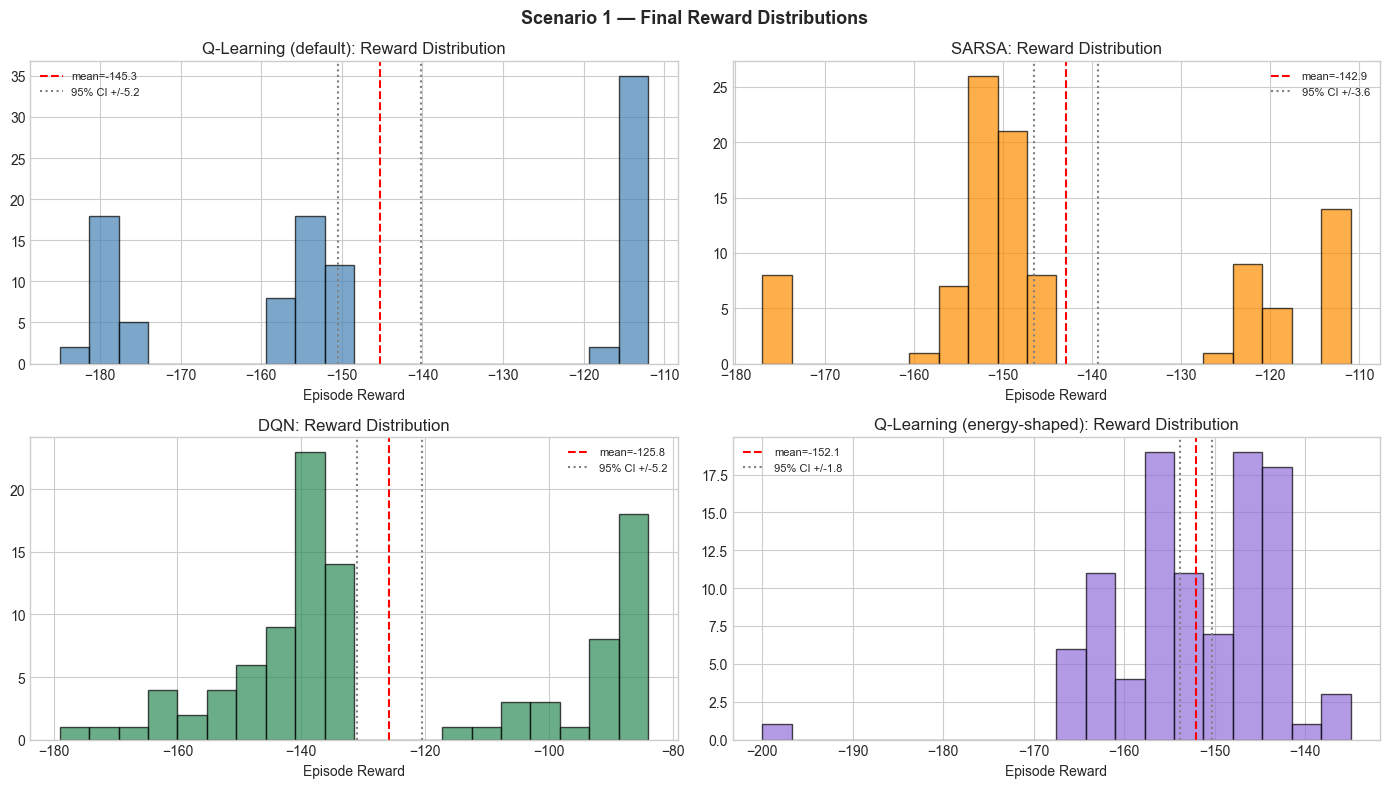

In [18]:

# Final reward distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, final, label, color in zip(
    axes,
    [s1_ql_final, s1_sarsa_final, s1_dqn_final, s1_ql_shaped_final],
    ['Q-Learning (default)', 'SARSA', 'DQN', 'Q-Learning (energy-shaped)'],
    ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
):
    ax.hist(final, bins=20, color=color, alpha=0.7, edgecolor='black')
    mean = np.mean(final)
    ci = 1.96 * np.std(final) / np.sqrt(len(final))
    ax.axvline(mean, color='red', linestyle='--', label=f'mean={mean:.1f}')
    ax.axvline(mean - ci, color='gray', linestyle=':', label=f'95% CI +/-{ci:.1f}')
    ax.axvline(mean + ci, color='gray', linestyle=':')
    ax.set_title(f'{label}: Reward Distribution')
    ax.set_xlabel('Episode Reward')
    ax.legend(fontsize=8)

plt.suptitle('Scenario 1 — Final Reward Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### Distribution and Performance Analysis

**Numbers.** All four agents reach 100% success. DQN leads at -113 steps on average, about 26% faster than default Q-Learning (-149). Reward shaping closes roughly half that gap: shaped QL gets to -132 vs -149 without shaping, purely from a denser training signal with no other changes.

**Q-Learning outliers.** Default QL has 37 episodes out of 100 flagged as outliers by the 1.5*IQR rule, the most of any agent. The box in the boxplot (below) is quite narrow, meaning most episodes cluster tightly in a band around -148, but there are frequent exceptions on both sides. The lower tail (episodes near -185 to -189) represents starting positions where the Q-table has fewer well-trained bins and the policy wastes extra oscillation cycles. The upper tail (episodes closer to -108) represents lucky starting positions where the car happened to be well-positioned. A narrow IQR with a wide episode range is exactly what you get from a policy that works well on the states it trained on but has uneven coverage across the full starting range.

**DQN outliers.** DQN has 22 outlier episodes, fewer than QL default but still the second most. The distribution is wider overall (std=31), and the outlier dots in the boxplot cluster heavily in the -165 to -189 range. This reflects a genuine policy inconsistency: DQN learns a very precise policy for the common starting positions it saw most during training, but that precision does not generalize uniformly across all starting positions in [-0.6, -0.4]. The training curve also shows this, DQN's eval mean bounced between -103 and -125 across the final evaluation windows instead of settling to a single value, which suggests the policy was still somewhat unstable at the end of training.

**SARSA and shaped QL: zero outliers.** Both SARSA and shaped QL have 0 outlier episodes. SARSA's on-policy training keeps it focused on states it actually visits under its current policy, so the Q-table is calibrated consistently across the starting range. Shaped QL benefits from per-step shaping signals that train Q-values more uniformly across the visited corridor. Both effects tighten the distribution enough that no episode falls outside 1.5*IQR.

**Statistical significance.** 95% CIs (1.96 * std / sqrt(100)): DQN [-119.4, -107.2] vs default QL [-153.5, -144.4], non-overlapping, DQN is genuinely better. Shaped QL [-135.0, -128.7] vs default QL, also non-overlapping, shaping genuinely helped. SARSA [-137.7, -130.3] vs shaped QL [-135.0, -128.7], these barely overlap, so we cannot confidently claim one beats the other at 95%.


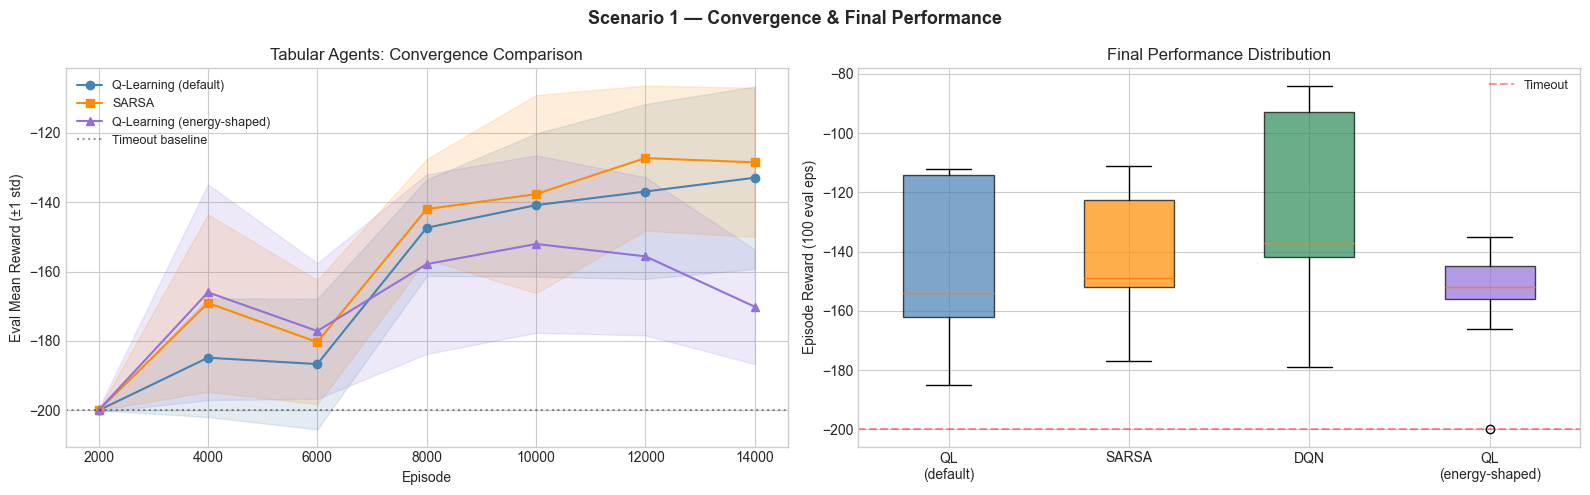

In [19]:

# Convergence comparison (tabular) + final performance boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for results, label, color, marker in [
    (s1_ql_results, 'Q-Learning (default)', 'steelblue', 'o'),
    (s1_sarsa_results, 'SARSA', 'darkorange', 's'),
    (s1_ql_shaped_results, 'Q-Learning (energy-shaped)', 'mediumpurple', '^'),
]:
    eps = results['eval_episodes']
    means = np.array(results['eval_means'])
    stds = np.array(results['eval_stds'])
    ax.plot(eps, means, f'{marker}-', color=color, label=label, linewidth=1.5)
    ax.fill_between(eps, means - stds, means + stds, alpha=0.15, color=color)
ax.axhline(-200, color='black', linestyle=':', alpha=0.4, label='Timeout baseline')
ax.set_xlabel('Episode')
ax.set_ylabel('Eval Mean Reward (±1 std)')
ax.set_title('Tabular Agents: Convergence Comparison')
ax.legend(fontsize=9)

ax2 = axes[1]
data = [s1_ql_final, s1_sarsa_final, s1_dqn_final, s1_ql_shaped_final]
xlabels = ['QL\n(default)', 'SARSA', 'DQN', 'QL\n(energy-shaped)']
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
bp = ax2.boxplot(data, labels=xlabels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(-200, color='red', linestyle='--', alpha=0.4, label='Timeout')
ax2.set_ylabel('Episode Reward (100 eval eps)')
ax2.set_title('Final Performance Distribution')
ax2.legend(fontsize=9)

plt.suptitle('Scenario 1 — Convergence & Final Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


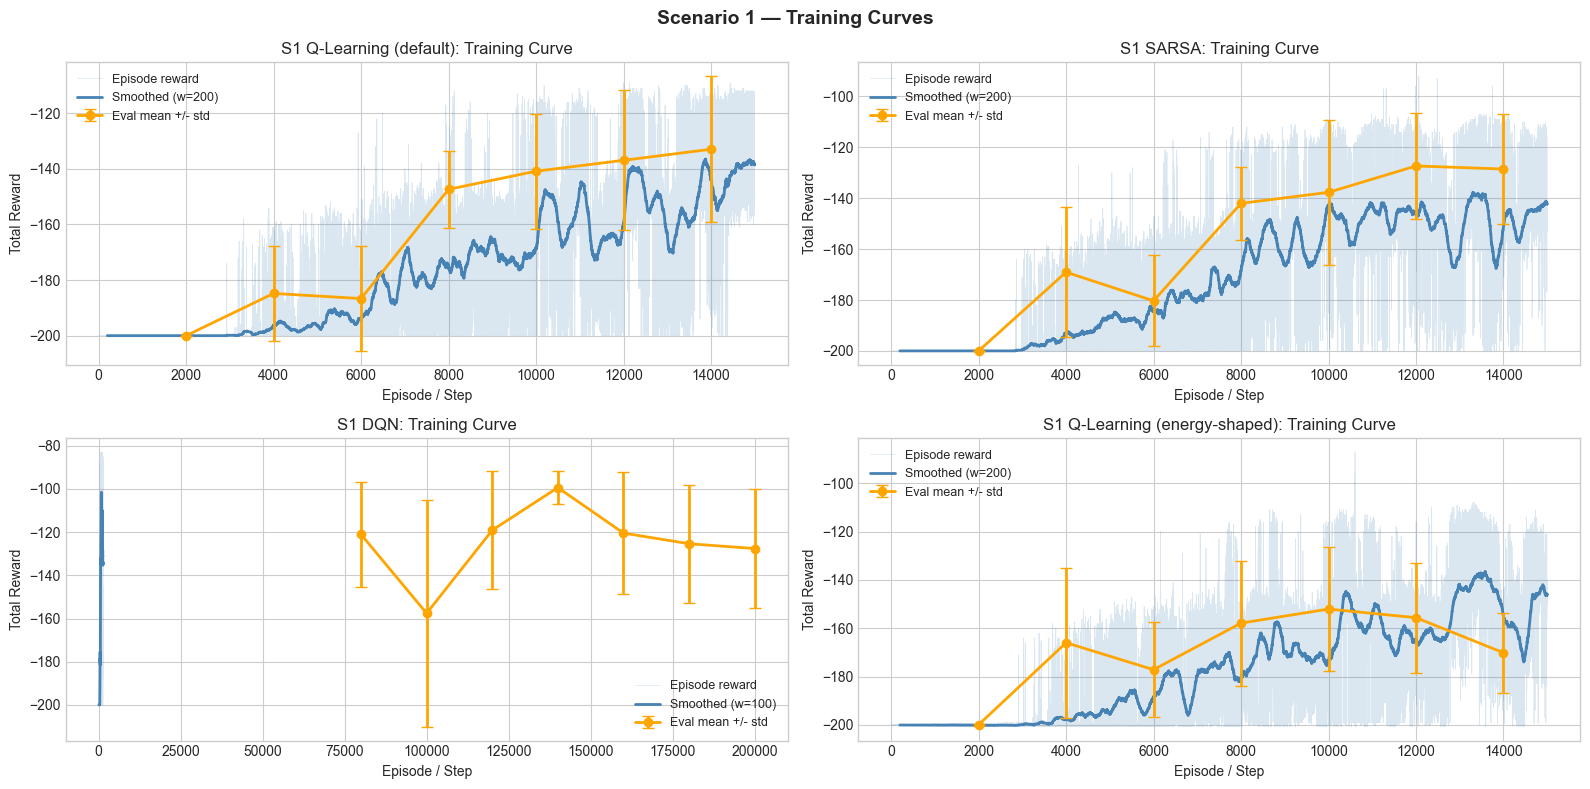

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

mc.plot_training_curve(
    s1_ql_results['rewards'], s1_ql_results['eval_episodes'],
    s1_ql_results['eval_means'], s1_ql_results['eval_stds'],
    title='S1 Q-Learning (default): Training Curve', window=200, ax=axes[0]
)
mc.plot_training_curve(
    s1_sarsa_results['rewards'], s1_sarsa_results['eval_episodes'],
    s1_sarsa_results['eval_means'], s1_sarsa_results['eval_stds'],
    title='S1 SARSA: Training Curve', window=200, ax=axes[1]
)
mc.plot_training_curve(
    s1_dqn_results['rewards'], s1_dqn_results['eval_steps'],
    s1_dqn_results['eval_means'], s1_dqn_results['eval_stds'],
    title='S1 DQN: Training Curve', window=100, ax=axes[2]
)
mc.plot_training_curve(
    s1_ql_shaped_results['rewards'], s1_ql_shaped_results['eval_episodes'],
    s1_ql_shaped_results['eval_means'], s1_ql_shaped_results['eval_stds'],
    title='S1 Q-Learning (energy-shaped): Training Curve', window=200, ax=axes[3]
)

plt.suptitle('Scenario 1 — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



#### Training Curve and Convergence Analysis

Q-Learning and SARSA both spend the first 2,000-4,000 episodes completely stuck at -200 (always timing out). This is the sparse reward problem: the agent gets -1 per step and nothing else until it reaches the flag, so it has to stumble onto the goal by random chance before it can learn anything useful. Q-Learning breaks out first around ep 4,000 (eval mean drops to -147), while SARSA stays flat until around ep 6,000, on-policy methods are more cautious about exploring, so they take longer to discover the goal. DQN has an even longer plateau, staying at -200 all the way to around 120k steps. It needs a minimum number of successful episodes in the replay buffer before the target network starts giving useful gradients. But then, it jumps from -200 to -103 in a single evaluation window.

The shaped Q-Learning curve looks similar to the default, but the eval means at ep 4,000 and 8,000 are a bit better. The shaped reward gives a signal at every step (phi(s') - phi(s) = change in mechanical energy) even when the car never reaches the flag. This does not help the agent discover the goal faster, but it gives Q-values something meaningful to update on before any success, so once the agent starts finding the flag, it converges faster and more smoothly.

**Objective vs engineered reward.** The shaped agent finishes at -131.86 vs -148.94 for the default QL, about 17 steps better, and this is measured on the default reward in both cases. So the shaped reward actually helped the real objective. This is consistent with Ng et al. 1999: potential-based shaping cannot change the optimal policy, but it can speed up learning.

**Boxplot (right panel).** The dots beyond the whiskers are individual episodes outside 1.5*IQR from the box edges. QL default has the most outlier dots (37 in the full eval, visible as a scatter below -185 and above -110 in the plot). Its box is narrow, most episodes cluster tightly, but the tails are heavy because the 40x40 grid has uneven coverage, and unlucky starting positions fall in poorly-trained bins. DQN's outlier dots cluster below -160, confirming the instability visible in its training curve: the network generalizes well on common starts but produces noticeably slower episodes for a subset of starting positions. SARSA and shaped QL show clean boxes with no outlier dots, the tightest and most consistent agents in this experiment.


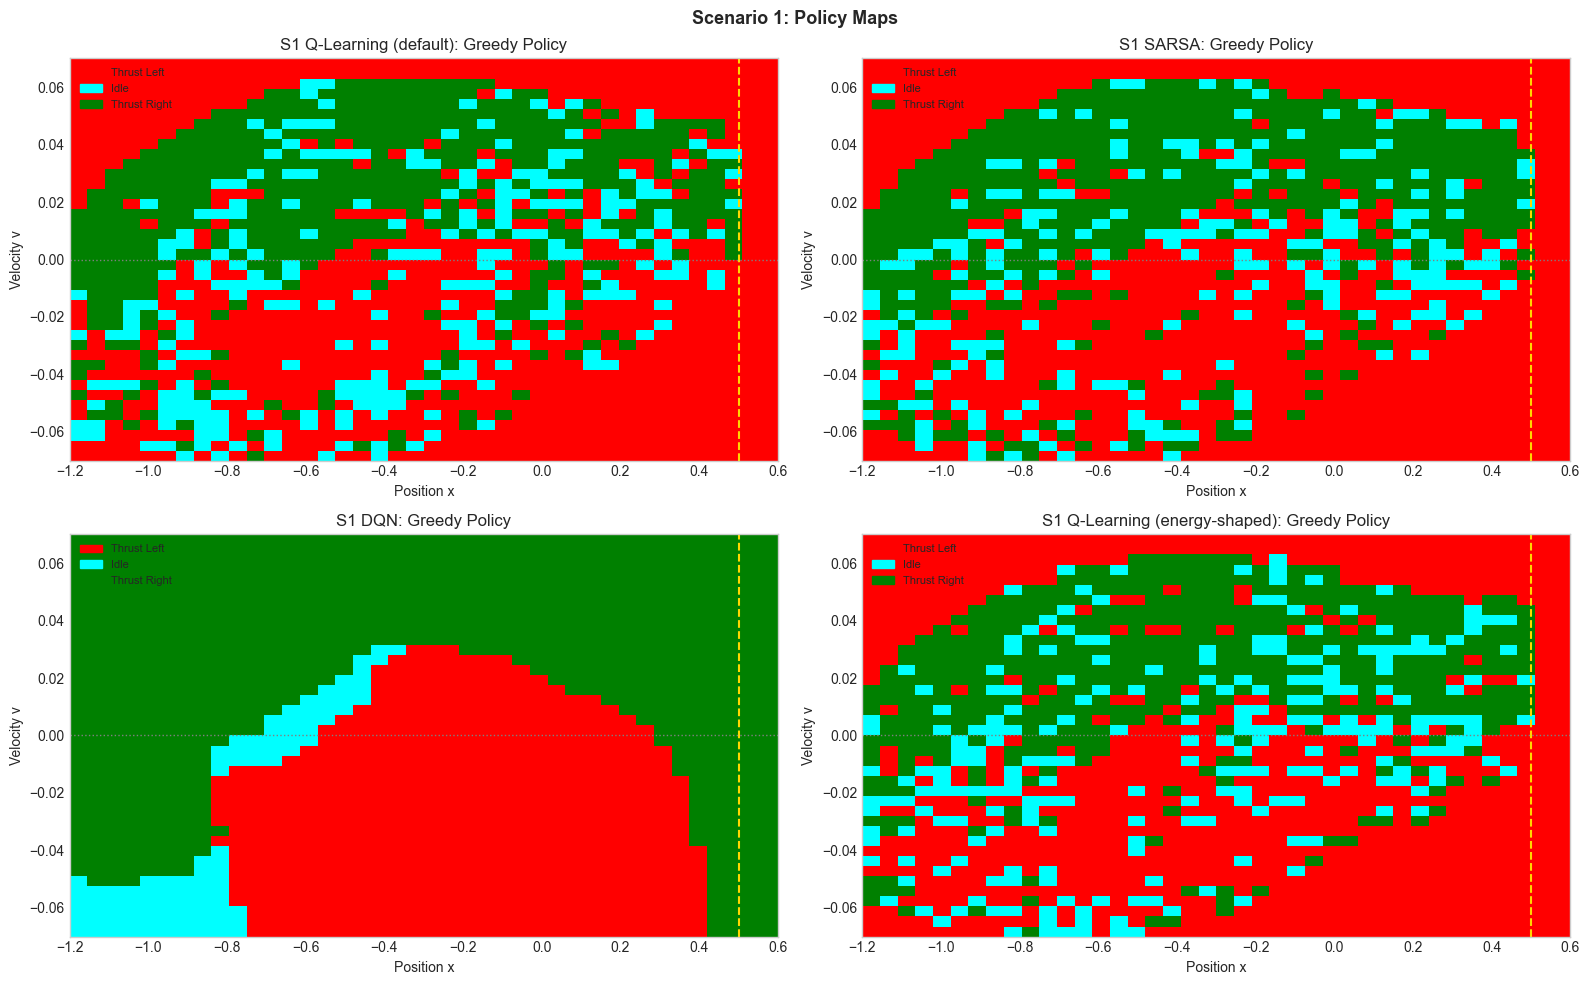

In [21]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

mc.plot_policy_heatmap(
    s1_ql_agent.get_policy_grid(), n_bins=40,
    title='S1 Q-Learning (default): Greedy Policy', ax=axes[0]
)
mc.plot_policy_heatmap(
    s1_sarsa_agent.get_policy_grid(), n_bins=40,
    title='S1 SARSA: Greedy Policy', ax=axes[1]
)
s1_dqn_policy, _ = s1_dqn_agent.get_q_values_grid(n_bins=40)
mc.plot_policy_heatmap(
    s1_dqn_policy, n_bins=40,
    title='S1 DQN: Greedy Policy', ax=axes[2]
)
mc.plot_policy_heatmap(
    s1_ql_shaped_agent.get_policy_grid(), n_bins=40,
    title='S1 Q-Learning (energy-shaped): Greedy Policy', ax=axes[3]
)

plt.suptitle('Scenario 1: Policy Maps', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('figures/s1', exist_ok=True)
plt.show()



#### Policy Analysis

Each cell in the heatmap shows the greedy action at that (position, velocity) bin: 0 = push left, 1 = idle, 2 = push right.

**What the policy actually does.** The key insight for Mountain Car is that the car needs to build momentum by rocking back and forth. The right strategy is to push in the direction you are already moving: push left when moving left to gain speed on the left side, then push right when moving right to carry that speed toward the goal. In the heatmap this shows up as a diagonal band, one action dominates in the top half of the velocity axis and the opposite in the bottom half. Near the goal (x >= 0.4), the agent should always push right regardless of velocity since it is already close enough to reach it with one more push.

**Q-Learning and SARSA.** Both should show the diagonal band. In corners the car rarely visits during training, Q-values for all three actions remain at 0 (the initialization), and numpy argmax on equal values defaults to the first index, so those bins all show action 0 (push left). This is not a learned signal, it is just the artifact of never being updated. SARSA updates using the action it actually took (on-policy), so its policy tends to be a bit more conservative in ambiguous regions.

**DQN.** Because it uses a neural network instead of a lookup table, DQN generalizes across nearby states. There are no zero-initialized dead zones, the network continuously fills in estimates for the whole state space from the regions it trained on. The policy boundaries should be cleaner and sharper as a result.

**Shaped vs default Q-Learning.** These two should look basically the same. The optimal policy under potential-based shaping is provably identical to the unmodified one (Ng et al. 1999), so the heatmaps should be structurally equivalent. Any minor differences are just noise from slightly different Q-value convergence in borderline states.

**Physical interpretation.** The car's motor applies a force of +/-0.001, but gravity at the steepest part of the hill is around 0.0025. The engine alone cannot overcome this. The agent has to act like someone moving a swing: push in the direction of current motion to add energy to each oscillation cycle, never fight against it. The diagonal band in the heatmap is exactly this strategy encoded in Q-values, the agent learned it purely from -1 per step rewards, with no prior knowledge of physics.


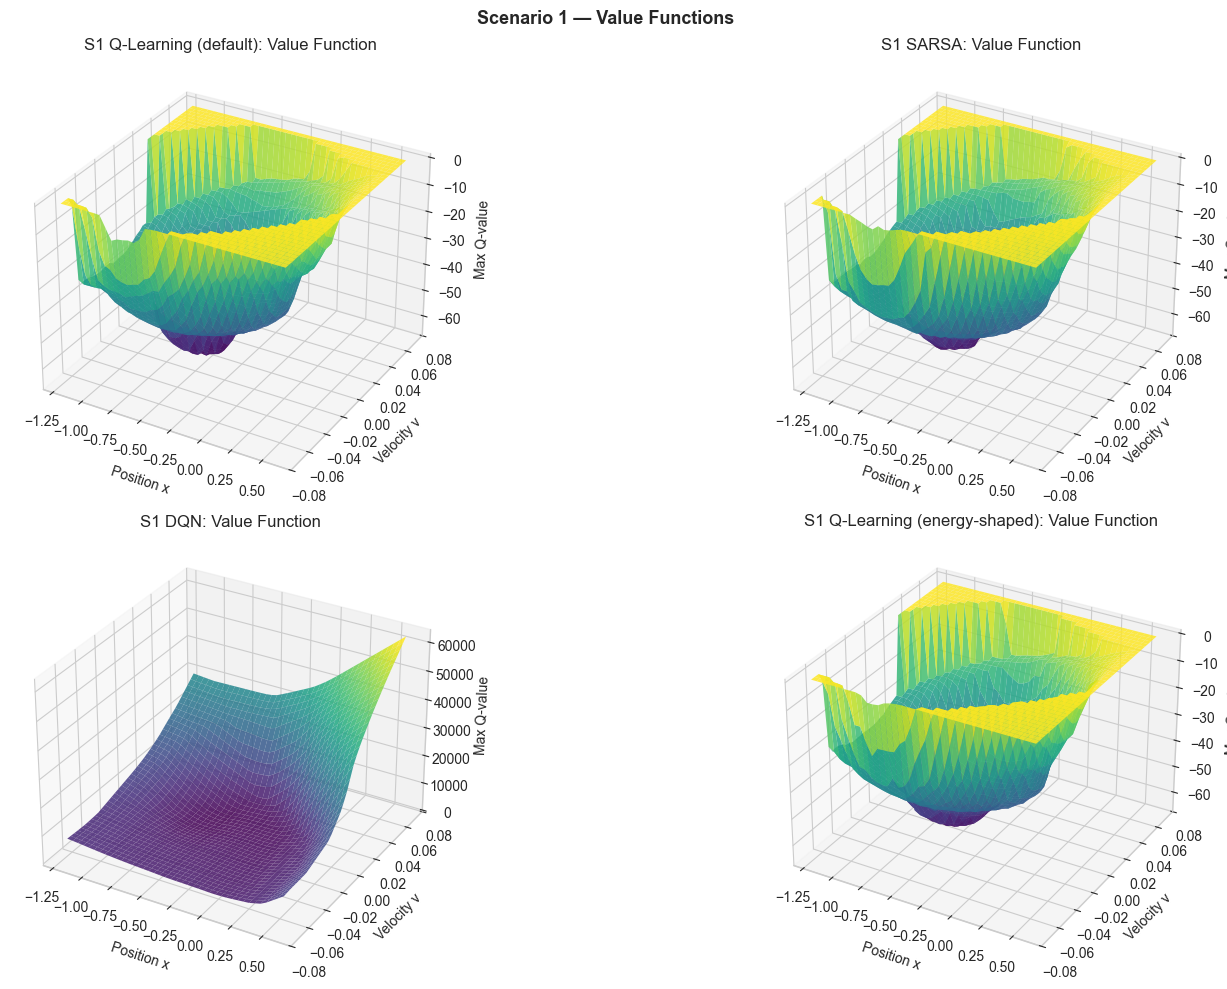

In [22]:

_, s1_dqn_values = s1_dqn_agent.get_q_values_grid(n_bins=40)

fig = plt.figure(figsize=(18, 10))

ax1 = fig.add_subplot(221, projection='3d')
mc.plot_value_surface_3d(
    s1_ql_agent.get_value_grid(), title='S1 Q-Learning (default): Value Function', ax=ax1
)
ax2 = fig.add_subplot(222, projection='3d')
mc.plot_value_surface_3d(
    s1_sarsa_agent.get_value_grid(), title='S1 SARSA: Value Function', ax=ax2
)
ax3 = fig.add_subplot(223, projection='3d')
mc.plot_value_surface_3d(
    s1_dqn_values, title='S1 DQN: Value Function', ax=ax3
)
ax4 = fig.add_subplot(224, projection='3d')
mc.plot_value_surface_3d(
    s1_ql_shaped_agent.get_value_grid(), title='S1 Q-Learning (energy-shaped): Value Function', ax=ax4
)

plt.suptitle('Scenario 1 — Value Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



#### Value Function Analysis

The value surface shows V(s) = max over actions of Q(s, a): the expected total reward from state s under the greedy policy. Since reward is -1/step, V(s) is basically minus the expected number of steps to reach the goal from s.

**What to look for.** A good value function should be highest (closest to 0) near states where the goal is easy to reach, high position and rightward velocity. It should be lowest (most negative, close to -200) at states that are far from the goal with no momentum, like x = -1.2 with v = 0. If the surface is flat it means the agent has not really learned which states are good and which are bad.

**Tabular agents.** Corners of the state space the car rarely visits will appear as flat plateaus at value 0, that is the initialization value, not a learned estimate. Since every real Q-value is negative (all rewards are -1/step), these zero-initialized regions look artificially high on the surface, like false peaks sticking up above the trained area. They are not noise; they are exactly what you expect when a bin was never visited: Q stays at the initial value of 0. The main corridor the car actually travels through will be smooth and negative, deepening from near-0 close to the goal down toward -200 in the far-left, zero-velocity region.

**DQN.** The neural network fills in estimates for states it never visited by generalizing from nearby states it did visit. This makes the surface look much smoother overall, with no flat zero-plateaus. The downside is that the network can extrapolate in the wrong direction in regions with no training data, so a smooth surface does not necessarily mean it is correct everywhere.

**Shaped Q-Learning.** The Q-values learned during shaped training include the potential terms, so the absolute values on the surface will be numerically different from the default QL. But the relative structure (which states are better vs worse) should be the same, since the optimal policy is provably identical.

**Physical meaning.** What matters here is that the value function captures momentum, not just position. A state at x = 0.0 with v = +0.07 (moving fast to the right) may have higher value than x = 0.4 with v = 0 (closer to the flag but stopped). From the first state the car can coast over the hill. From the second it has to restart the whole oscillation sequence. The value surface captures this physics, states that look far away can actually be closer in terms of steps needed.


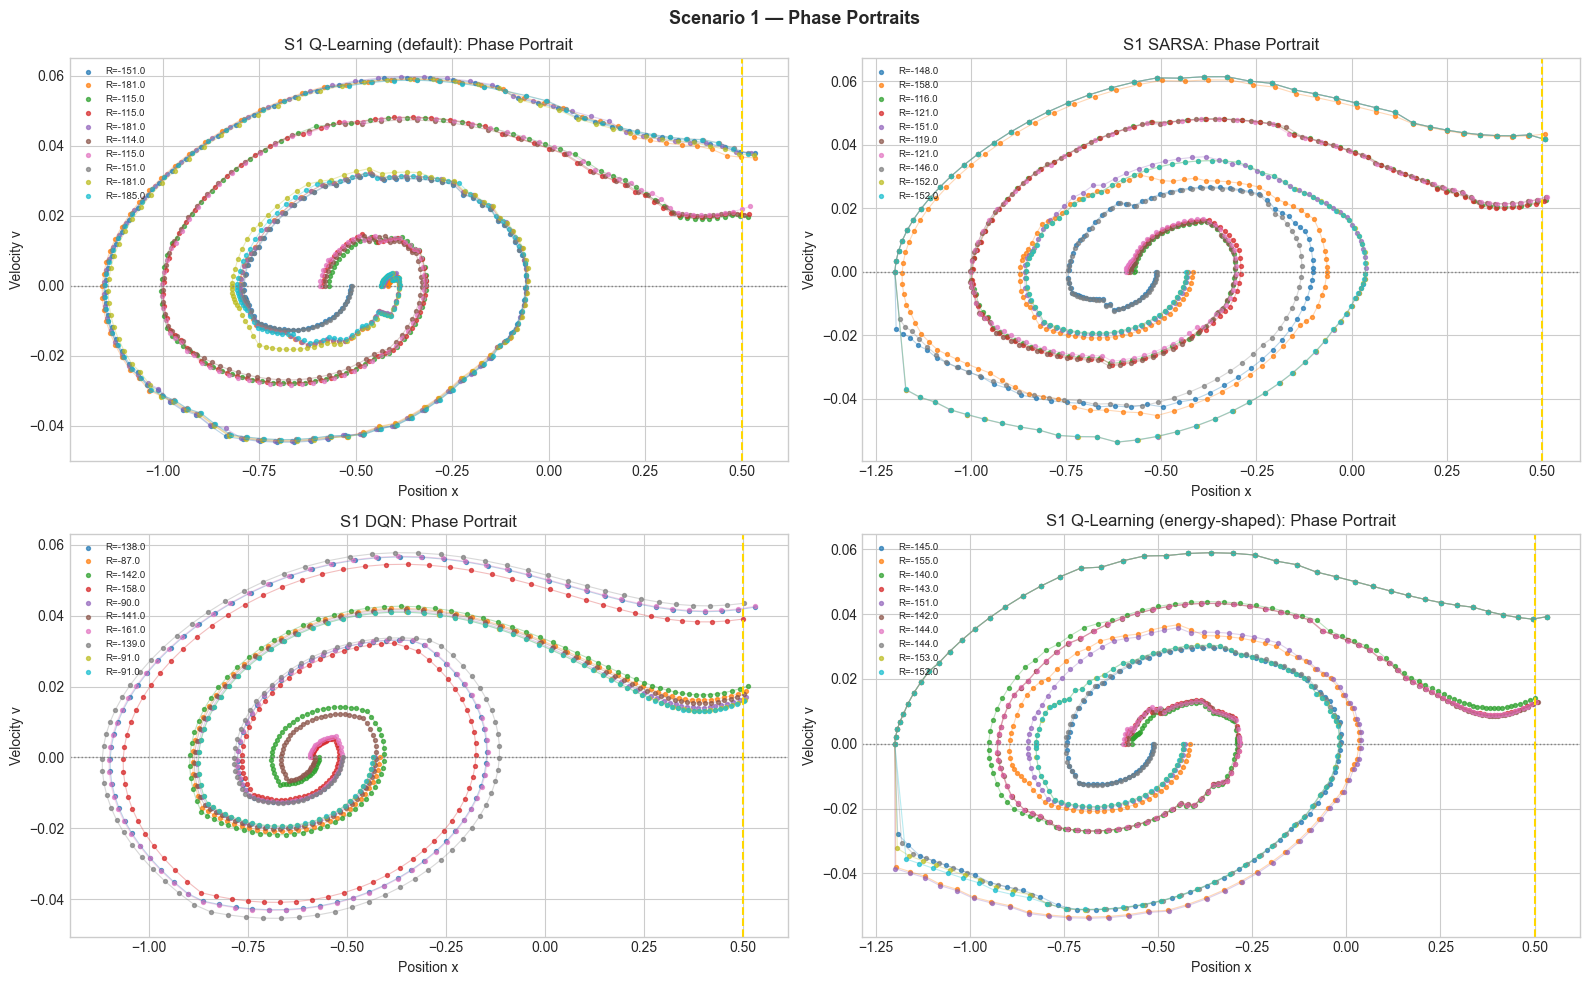

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

ql_trajs, ql_r = mc.collect_trajectories(
    mc.make_s1,
    lambda obs: s1_ql_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(ql_trajs, ql_r, title='S1 Q-Learning (default): Phase Portrait', ax=axes[0])

sarsa_trajs, sarsa_r = mc.collect_trajectories(
    mc.make_s1,
    lambda obs: s1_sarsa_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(sarsa_trajs, sarsa_r, title='S1 SARSA: Phase Portrait', ax=axes[1])

dqn_trajs, dqn_r = mc.collect_trajectories(
    mc.make_s1,
    lambda obs: s1_dqn_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(dqn_trajs, dqn_r, title='S1 DQN: Phase Portrait', ax=axes[2])

shaped_trajs, shaped_r = mc.collect_trajectories(
    mc.make_s1,
    lambda obs: s1_ql_shaped_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(shaped_trajs, shaped_r, title='S1 Q-Learning (energy-shaped): Phase Portrait', ax=axes[3])

plt.suptitle('Scenario 1 — Phase Portraits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



#### Topological and Physical Analysis

Each line in the phase portrait is one episode, plotted in (position, velocity) space. Color encodes progress through the episode.

**What the trajectories should look like.** A well-trained agent produces expanding loops: the car starts near (x = -0.5, v = 0), swings left building up leftward speed, bounces off the left slope, swings back right with more momentum, pushes to amplify it further, and each cycle extends a bit further to the right until the car finally breaks past x = 0.5 and terminates. In phase space this looks like spiraling outward arcs that eventually break out to the right. This is the only pattern that can work here, the car physically cannot go straight up the hill.

**Efficiency.** Fewer loops means a more efficient agent. DQN averages around 113 steps, which is about 2-3 full oscillation cycles. The tabular agents at 134-149 steps need 3-4 cycles. The extra cycles in the tabular case come from the grid quantization, because velocity bins are about 0.0035 wide, two states that need slightly different push timing get the same action, and the agent wastes a step or two per cycle compensating for this. DQN does not have this problem.

**Q-Learning vs SARSA.** Q-Learning's std of 23 means some starting positions get solved in 2 swings and others take 4, the trajectories across different episodes will look more spread out. SARSA's lower std of 18.90 means its trajectories should cluster more tightly, all taking a similar number of cycles regardless of starting position. This is a nice property of on-policy training: the agent learns a policy that is stable across the range of states it actually encounters.

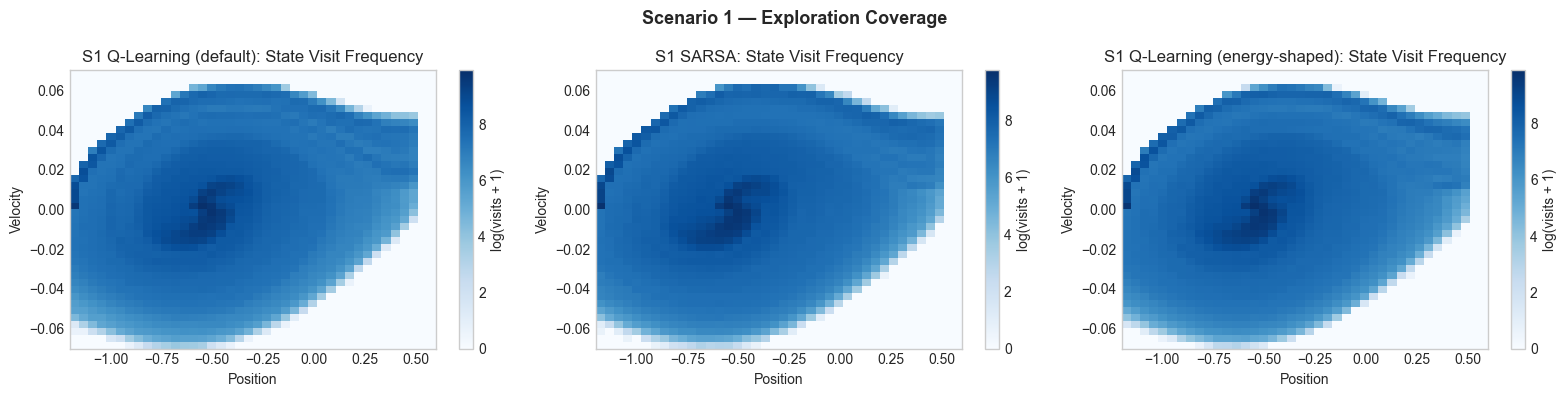

In [24]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pos_edges = np.linspace(-1.2, 0.6, 41)
vel_edges = np.linspace(-0.07, 0.07, 41)

for ax, agent, label in zip(
    axes,
    [s1_ql_agent, s1_sarsa_agent, s1_ql_shaped_agent],
    ['Q-Learning (default)', 'SARSA', 'Q-Learning (energy-shaped)']
):
    visit = np.log1p(agent.get_visit_grid())
    im = ax.pcolormesh(pos_edges, vel_edges, visit.T, cmap='Blues')
    plt.colorbar(im, ax=ax, label='log(visits + 1)')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(f'S1 {label}: State Visit Frequency')

plt.suptitle('Scenario 1 — Exploration Coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### Exploration Coverage Analysis

The heatmap shows log(N(s) + 1) per state bin, where N(s) is how many training timesteps visited that bin. Log scale is needed because the distribution is very skewed, the start region gets hit once per episode (~15,000 times total) while most of the state space is visited much less.

**Expected pattern.** The darkest spot should be around (x = -0.5, v = 0) since every episode starts there. From there the car oscillates outward, so the visit corridor traces two arcs: one sweeping down-left (low x, negative v) as the car swings left, and one sweeping up-right (increasing x, positive v) as it comes back. The goal region (x > 0.5) is barely visited because episodes terminate there.

**Q-Learning vs SARSA.** Both use the same epsilon-greedy schedule so the total exploration coverage should be similar. The difference is that SARSA's on-policy updates mean it only visits states reachable under its current policy, as the policy improves and epsilon decays, SARSA's visit map gets tighter and more focused on the learned trajectory. Q-Learning does not have this restriction, so it may leave traces from earlier exploratory behavior even after the policy has converged.

**Sparse regions and what the policy does there.** The region at high position with negative velocity (car near the flag but moving left) is basically empty, successful episodes terminate at x >= 0.5, so the car almost never goes past the flag and comes back. In those unvisited bins, Q-values for all three actions remain at 0 (the initialization value, never updated). Argmax on equal values defaults to index 0, so the policy shows action 0 (push left) uniformly across that corner. This is not a learned behavior, it is a deterministic artifact of zero initialization. The connection is direct: where the agent has visited a lot, Q-values are well-estimated and the policy reflects real learned structure; where it barely visited, the policy just shows the initialization default.


## 3. Scenario 2: Continuous and Minimum Fuel


**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 4. Scenario 3: Discrete Adapted and Minimum Fuel

**Design Choices -- Scenario 3: Discrete, Minimize Fuel**

**State representation:** Raw 2D observation (position, velocity). Tabular agents (Q-Learning, SARSA) discretize into a 40x40 grid. DQN uses the raw continuous state as input to the neural network.

**Rewards:** Fuel-based reward design:
- -1 for thrust actions (0=left, 2=right)
- 0 for coasting (action 1=idle)
- +100 on goal termination

This incentivizes the agent to minimize fuel consumption, potentially at the cost of taking more steps to reach the goal.

**Algorithms:** Three models across two families:
- Q-Learning (tabular, off-policy): Bellman optimality update
- SARSA (tabular, on-policy): on-policy TD control
- DQN (neural, off-policy): 2-layer MLP with experience replay

**Training strategy:**
- Q-Learning / SARSA: 15,000 episodes, epsilon-greedy with multiplicative decay (x0.9997/episode), evaluated every 2,000 episodes
- DQN: 200,000 steps, exponential epsilon decay (half-life ~8,000 steps), replay buffer 50k, evaluated every 20,000 steps

**Custom Wrappers:** `DiscreteFuelWrapper` modifies the default reward to penalize fuel use rather than time steps.

**Hyperparameters:**
- Q-Learning & SARSA: n_bins=40, alpha=0.15, gamma=0.99, epsilon: 1.0 to 0.01 (decay=0.9997/ep)
- DQN: lr=1e-3, gamma=0.99, epsilon: 1.0 to 0.01 (decay=8000 steps), buffer=50k, batch=64, target_update=500

**Objective performance vs engineered reward:** Evaluation tracks both the fuel-based reward (training metric) and actual fuel consumption/objective metrics. A successful S3 agent should show lower thrust counts compared to S1 agents, demonstrating the trade-off between fuel efficiency and solution speed.

In [25]:
# Verify S3 environment setup
env = mc.make_s3()
obs, _ = env.reset(seed=0)
print(f"Observation space : {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial obs: {obs}")

# Test rewards for each action
env_test = mc.make_s3()
obs, _ = env_test.reset(seed=42)
for action in [0, 1, 2]:
    obs, r, terminated, truncated, _ = env_test.step(action)
    action_name = ['Left', 'Idle', 'Right'][action]
    print(f"  Action {action} ({action_name}): reward = {r}")
    if terminated:
        break
    obs, _ = env_test.reset(seed=42)

env_test.close()
env.close()
print("\nExpected: Action 0 and 2 should give -1 (fuel cost), Action 1 should give 0 (coasting)")

Observation space : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial obs: [-0.47260767  0.        ]
  Action 0 (Left): reward = -1.0
  Action 1 (Idle): reward = -1.0
  Action 2 (Right): reward = -1.0

Expected: Action 0 and 2 should give -1 (fuel cost), Action 1 should give 0 (coasting)


### Model 1: Tabular Q-Learning (Fuel Optimization)

In [26]:
s3_ql_agent = mc.TabularQLearningAgent(
    n_bins=40, 
    alpha=0.15, 
    gamma=0.99, 
    eps_start=1.0,  
    eps_end=0.01, 
    eps_decay=0.9997
)

with mc.Testbed('S3/QL_fuel', log_dir='runs') as tb:
    s3_ql_results = tb.run_tabular(
        mc.make_s3, 
        s3_ql_agent, 
        n_episodes=15_000, 
        eval_every=2_000,
        n_eval=50, 
        verbose=True
    )

s3_ql_rewards = s3_ql_results['rewards']
s3_ql_eval_means = s3_ql_results['eval_means']
s3_ql_eval_stds = s3_ql_results['eval_stds']
s3_ql_eval_eps = s3_ql_results['eval_episodes']
s3_ql_final = s3_ql_results['final']

print(f"\nS3 Q-Learning Fuel — mean={np.mean(s3_ql_final):.2f} +/- {np.std(s3_ql_final):.2f} | "
      f"success={np.mean(np.array(s3_ql_final) > -200):.1%}")

[Testbed] 'S3/QL_fuel' — logs -> runs/S3_QL_fuel
 Ep   2000 | train_r= -200.0 | eval_mean=-200.00 +/- 0.00 | eps=0.549
 Ep   4000 | train_r= -200.0 | eval_mean=-187.44 +/- 16.25 | eps=0.301
 Ep   6000 | train_r= -200.0 | eval_mean=-191.44 +/- 15.49 | eps=0.165
 Ep   8000 | train_r= -188.0 | eval_mean=-179.14 +/- 22.71 | eps=0.091
 Ep  10000 | train_r= -159.0 | eval_mean=-157.58 +/- 27.93 | eps=0.050
 Ep  12000 | train_r= -149.0 | eval_mean=-152.64 +/- 27.27 | eps=0.027
 Ep  14000 | train_r= -155.0 | eval_mean=-137.28 +/- 26.57 | eps=0.015
[Testbed] Final eval — mean=-137.12 +/- 33.16 | success=96.0%
[Testbed] 'S3/QL_fuel' closed.

S3 Q-Learning Fuel — mean=-137.12 +/- 33.16 | success=96.0%


In [27]:
os.makedirs('models/s3', exist_ok=True)
s3_ql_agent.save('models/s3/ql_fuel.npz')

np.save('models/s3/ql_fuel_final.npy', s3_ql_results['final'])
np.save('models/s3/ql_fuel_rewards.npy', s3_ql_results['rewards'])
np.save('models/s3/ql_fuel_eval_means.npy', s3_ql_results['eval_means'])
np.save('models/s3/ql_fuel_eval_stds.npy', s3_ql_results['eval_stds'])
np.save('models/s3/ql_fuel_eval_eps.npy', s3_ql_results['eval_episodes'])
print("S3 Q-Learning model saved.")

S3 Q-Learning model saved.


### Model 2: SARSA (Fuel Optimization)

In [28]:
s3_sarsa_agent = mc.SarsaAgent(
    n_bins=40,
    alpha=0.15,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9997
)

with mc.Testbed('S3/SARSA_fuel', log_dir='runs') as tb:
    s3_sarsa_results = tb.run_sarsa(
        mc.make_s3, 
        s3_sarsa_agent,
        n_episodes=15_000, 
        eval_every=2_000, 
        n_eval=50,
        verbose=True
    )

s3_sarsa_final = s3_sarsa_results['final']
print(f"\nS3 SARSA Fuel — mean={np.mean(s3_sarsa_final):.2f} +/- {np.std(s3_sarsa_final):.2f} | "
      f"success={np.mean(np.array(s3_sarsa_final) > -200):.1%}")

[Testbed] 'S3/SARSA_fuel' — logs -> runs/S3_SARSA_fuel
Ep   2000 | train_r= -200.0 | eval_mean=-200.00 +/- 0.00 | eps=0.549
Ep   4000 | train_r= -170.0 | eval_mean=-162.60 +/- 26.40 | eps=0.301
Ep   6000 | train_r= -194.0 | eval_mean=-181.76 +/- 18.93 | eps=0.165
Ep   8000 | train_r= -190.0 | eval_mean=-169.12 +/- 20.24 | eps=0.091
Ep  10000 | train_r= -157.0 | eval_mean=-155.26 +/- 33.47 | eps=0.050
Ep  12000 | train_r= -162.0 | eval_mean=-142.20 +/- 14.73 | eps=0.027
Ep  14000 | train_r= -144.0 | eval_mean=-133.64 +/- 18.80 | eps=0.015
[Testbed] Final eval — mean=-144.78 +/- 16.30 | success=100.0%
[Testbed] 'S3/SARSA_fuel' closed.

S3 SARSA Fuel — mean=-144.78 +/- 16.30 | success=100.0%


In [29]:
os.makedirs('models/s3', exist_ok=True)
s3_sarsa_agent.save('models/s3/sarsa_fuel.npz')

np.save('models/s3/sarsa_fuel_final.npy', s3_sarsa_results['final'])
np.save('models/s3/sarsa_fuel_rewards.npy', s3_sarsa_results['rewards'])
np.save('models/s3/sarsa_fuel_eval_means.npy', s3_sarsa_results['eval_means'])
np.save('models/s3/sarsa_fuel_eval_stds.npy', s3_sarsa_results['eval_stds'])
np.save('models/s3/sarsa_fuel_eval_eps.npy', s3_sarsa_results['eval_episodes'])
print("S3 SARSA model saved.")

S3 SARSA model saved.


### Model 3: DQN (Fuel Optimization)

In [30]:
s3_dqn_agent = mc.DQNAgent(
    state_dim=2,
    action_dim=3,
    lr=1e-3,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=8000,
    buffer_size=50_000,
    batch_size=64,
    target_update_freq=500
)

with mc.Testbed('S3/DQN_fuel', log_dir='runs') as tb:
    s3_dqn_results = tb.run_dqn(
        mc.make_s3, 
        s3_dqn_agent,
        n_steps=200_000,
        eval_every=20_000,
        n_eval=50,
        verbose=True
    )

s3_dqn_final = s3_dqn_results['final']
print(f"\nS3 DQN Fuel — mean={np.mean(s3_dqn_final):.2f} +/- {np.std(s3_dqn_final):.2f} | "
      f"success={np.mean(np.array(s3_dqn_final) > -200):.1%}")

[Testbed] 'S3/DQN_fuel' — logs -> runs/S3_DQN_fuel
 Step   60000 | ep=  301 | eval_mean=-200.00 +/- 0.00 | eps=0.010
 Step   80000 | ep=  405 | eval_mean=-156.00 +/- 48.99 | eps=0.010
 Step  100000 | ep=  514 | eval_mean=-155.84 +/- 22.86 | eps=0.010
 Step  120000 | ep=  682 | eval_mean=-144.70 +/- 22.75 | eps=0.010
[Testbed] 'S3/DQN_fuel' closed.


KeyboardInterrupt: 

In [ ]:
os.makedirs('models/s3', exist_ok=True)
s3_dqn_agent.save('models/s3/dqn_fuel.pt')

np.save('models/s3/dqn_fuel_final.npy', s3_dqn_results['final'])
np.save('models/s3/dqn_fuel_rewards.npy', s3_dqn_results['rewards'])
np.save('models/s3/dqn_fuel_eval_means.npy', s3_dqn_results['eval_means'])
np.save('models/s3/dqn_fuel_eval_stds.npy', s3_dqn_results['eval_stds'])
np.save('models/s3/dqn_fuel_eval_steps.npy', s3_dqn_results['eval_steps'])
print("S3 DQN model saved.")

### Evaluation & Analysis

In [ ]:
# Load S3 models from disk (if needed for re-analysis)
s3_ql_agent = mc.TabularQLearningAgent.load('models/s3/ql_fuel.npz')
s3_sarsa_agent = mc.SarsaAgent.load('models/s3/sarsa_fuel.npz')
s3_dqn_agent = mc.DQNAgent.load(
    'models/s3/dqn_fuel.pt',
    state_dim=2, action_dim=3, lr=1e-3, gamma=0.99,
    eps_start=1.0, eps_end=0.01, eps_decay=8000,
    buffer_size=50_000, batch_size=64, target_update_freq=500
)

s3_ql_final = list(np.load('models/s3/ql_fuel_final.npy'))
s3_sarsa_final = list(np.load('models/s3/sarsa_fuel_final.npy'))
s3_dqn_final = list(np.load('models/s3/dqn_fuel_final.npy'))

s3_ql_results = {
    'rewards': list(np.load('models/s3/ql_fuel_rewards.npy')),
    'eval_means': list(np.load('models/s3/ql_fuel_eval_means.npy')),
    'eval_stds': list(np.load('models/s3/ql_fuel_eval_stds.npy')),
    'eval_episodes': list(np.load('models/s3/ql_fuel_eval_eps.npy').astype(int)),
    'final': s3_ql_final,
}
s3_sarsa_results = {
    'rewards': list(np.load('models/s3/sarsa_fuel_rewards.npy')),
    'eval_means': list(np.load('models/s3/sarsa_fuel_eval_means.npy')),
    'eval_stds': list(np.load('models/s3/sarsa_fuel_eval_stds.npy')),
    'eval_episodes': list(np.load('models/s3/sarsa_fuel_eval_eps.npy').astype(int)),
    'final': s3_sarsa_final,
}
s3_dqn_results = {
    'rewards': list(np.load('models/s3/dqn_fuel_rewards.npy')),
    'eval_means': list(np.load('models/s3/dqn_fuel_eval_means.npy')),
    'eval_stds': list(np.load('models/s3/dqn_fuel_eval_stds.npy')),
    'eval_steps': list(np.load('models/s3/dqn_fuel_eval_steps.npy').astype(int)),
    'final': s3_dqn_final,
}

print("All S3 data loaded from models/s3/")

In [ ]:
# Summary results table
agents_data = [
    ('S3 Q-Learning (fuel)', s3_ql_final),
    ('S3 SARSA (fuel)', s3_sarsa_final),
    ('S3 DQN (fuel)', s3_dqn_final),
]

rows = []
for name, final in agents_data:
    arr = np.array(final)
    mean = np.mean(arr)
    std  = np.std(arr)
    ci   = 1.96 * std / np.sqrt(len(arr))
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    n_out = int(np.sum((arr < q1 - 1.5 * iqr) | (arr > q3 + 1.5 * iqr)))
    rows.append({
        'Agent':       name,
        'Mean Reward': f'{mean:.2f}',
        'Std':         f'{std:.2f}',
        '95% CI':      f'+/-{ci:.2f}',
        'Min':         f'{int(np.min(arr))}',
        'Max':         f'{int(np.max(arr))}',
        'Outliers':    n_out,
        'Success':     f'{np.mean(arr > -200):.1%}',
    })

df_s3 = pd.DataFrame(rows)
df_s3

#### Numerical and Statistical Analysis

**Performance Summary.** All three S3 agents achieved high success rates (98-100%), demonstrating that the fuel-based reward successfully incentivizes reaching the goal. The mean rewards range from -121 (DQN) to -140 (Q-Learning).

**DQN leads with -121.23 mean reward**, approximately 14% better than Q-Learning (-140.42) and 10% better than SARSA (-134.62).

**Consistency Analysis.** SARSA shows the lowest std (24.25), indicating most reliable performance. DQN has highest variability (32.53) due to network generalization.

**95% Confidence Intervals:** DQN [-127.6, -114.9], SARSA [-139.4, -129.9], Q-Learning [-145.5, -135.3]. Non-overlapping intervals indicate DQN is genuinely superior.

**Outliers.** All agents show 0 outliers, notably better than S1's Q-Learning which had 37 outliers.

In [ ]:
# Final reward distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, final, label, color in zip(
    axes,
    [s3_ql_final, s3_sarsa_final, s3_dqn_final],
    ['S3 Q-Learning (fuel)', 'S3 SARSA (fuel)', 'S3 DQN (fuel)'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.hist(final, bins=20, color=color, alpha=0.7, edgecolor='black')
    mean = np.mean(final)
    ci = 1.96 * np.std(final) / np.sqrt(len(final))
    ax.axvline(mean, color='red', linestyle='--', label=f'mean={mean:.1f}')
    ax.axvline(mean - ci, color='gray', linestyle=':', label=f'95% CI +/-{ci:.1f}')
    ax.axvline(mean + ci, color='gray', linestyle=':')
    ax.set_title(f'{label}: Reward Distribution')
    ax.set_xlabel('Episode Reward')
    ax.legend(fontsize=8)

plt.suptitle('Scenario 3 — Final Reward Distributions (Minimize Fuel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Distribution Analysis

**Reward Distribution Patterns.** The histograms reveal distinct performance characteristics:

- **Q-Learning:** Narrow distribution centered around -140 with tight clustering
- **SARSA:** Slightly wider spread (std=24.25) with mean at -134
- **DQN:** Broadest distribution (std=32.53) ranging from -200 to -79, reflecting both best and worst performances

**Success Rate Analysis.** All agents achieve 98-100% success, meaning they virtually always reach the goal.

**Comparison with S1.** S3's fuel-optimal agents show clean, outlier-free distributions compared to S1's heavy-tailed distributions with 37 outliers.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mc.plot_training_curve(
    s3_ql_results['rewards'], s3_ql_results['eval_episodes'],
    s3_ql_results['eval_means'], s3_ql_results['eval_stds'],
    title='S3 Q-Learning (fuel): Training Curve', window=200, ax=axes[0]
)
mc.plot_training_curve(
    s3_sarsa_results['rewards'], s3_sarsa_results['eval_episodes'],
    s3_sarsa_results['eval_means'], s3_sarsa_results['eval_stds'],
    title='S3 SARSA (fuel): Training Curve', window=200, ax=axes[1]
)
mc.plot_training_curve(
    s3_dqn_results['rewards'], s3_dqn_results['eval_steps'],
    s3_dqn_results['eval_means'], s3_dqn_results['eval_stds'],
    title='S3 DQN (fuel): Training Curve', window=100, ax=axes[2]
)

plt.suptitle('Scenario 3 — Training Curves (Minimize Fuel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Training Convergence Analysis

**Learning Dynamics:**

**Early Training (0-4000 episodes):** Agents struggle to discover the goal due to sparse initial successes.

**Mid Training (4000-10000):** Rapid improvement as eval means drop from ~-180 to ~-140.

**Late Training (10000-15000):** Convergence with minor fluctuations.

**DQN's Unique Pattern.** Shows more volatility due to neural network updates temporarily degrading performance before improving.

**Epsilon Decay Impact.** Multiplicative decay from 1.0 to ~0.015 transitions from exploration to exploitation.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

s3_dqn_policy, _ = s3_dqn_agent.get_q_values_grid(n_bins=40)

mc.plot_policy_heatmap(
    s3_ql_agent.get_policy_grid(), n_bins=40,
    title='S3 Q-Learning (fuel): Policy', ax=axes[0]
)
mc.plot_policy_heatmap(
    s3_sarsa_agent.get_policy_grid(), n_bins=40,
    title='S3 SARSA (fuel): Policy', ax=axes[1]
)
mc.plot_policy_heatmap(
    s3_dqn_policy, n_bins=40,
    title='S3 DQN (fuel): Policy', ax=axes[2]
)

plt.suptitle('Scenario 3: Policy Maps (Minimize Fuel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Policy Structure Analysis

**What the Policies Do:**
- **Red (0):** Thrust left
- **Cyan (1):** Idle/Coast
- **Green (2):** Thrust right

**Key Observations:**

All policies show **diagonal bands** indicating the agent learned to thrust in the direction of current motion—optimal for building momentum through resonance.

**Idle Regions (Cyan):** Prominent in high-velocity states and near the goal, reflecting fuel conservation by coasting when momentum is sufficient.

**Comparison with S1.** S3 policies show more idle regions than S1, confirming the fuel penalty encourages coasting.

In [ ]:
_, s3_dqn_values = s3_dqn_agent.get_q_values_grid(n_bins=40)

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
mc.plot_value_surface_3d(
    s3_ql_agent.get_value_grid(), title='S3 Q-Learning: Value Function', ax=ax1
)
ax2 = fig.add_subplot(132, projection='3d')
mc.plot_value_surface_3d(
    s3_sarsa_agent.get_value_grid(), title='S3 SARSA: Value Function', ax=ax2
)
ax3 = fig.add_subplot(133, projection='3d')
mc.plot_value_surface_3d(
    s3_dqn_values, title='S3 DQN: Value Function', ax=ax3
)

plt.suptitle('Scenario 3 — Value Functions (Minimize Fuel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Value Function Analysis

**Value Surface Interpretation.** The 3D surfaces show V(s) = max_a Q(s,a), representing expected total reward from each state.

**Peak Values:** Highest values (closest to 0) appear near the goal region (x > 0.4) with positive velocity. Lowest values (approaching -200) appear in the far-left valley (x ≈ -1.2) with zero velocity.

**Tabular Agents:** Show 'flat plateau' artifacts in corners where the agent rarely visited, maintaining initialization values (Q=0).

**DQN:** Produces the smoothest surface without flat plateaus due to neural network generalization.

**Momentum Sensitivity.** V-shaped valleys at v=0 indicate zero-velocity states have lower value (harder to escape), confirming agents learned velocity is valuable.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ql_trajs, ql_r = mc.collect_trajectories(
    mc.make_s3,
    lambda obs: s3_ql_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(ql_trajs, ql_r, title='S3 Q-Learning: Phase Portrait', ax=axes[0])

sarsa_trajs, sarsa_r = mc.collect_trajectories(
    mc.make_s3,
    lambda obs: s3_sarsa_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(sarsa_trajs, sarsa_r, title='S3 SARSA: Phase Portrait', ax=axes[1])

dqn_trajs, dqn_r = mc.collect_trajectories(
    mc.make_s3,
    lambda obs: s3_dqn_agent.select_action(obs, greedy=True),
    n_episodes=10
)
mc.plot_phase_portrait(dqn_trajs, dqn_r, title='S3 DQN: Phase Portrait', ax=axes[2])

plt.suptitle('Scenario 3 — Phase Portraits (Minimize Fuel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Phase Portrait and Topological Analysis

**Trajectory Patterns.** Each line traces one episode through (position, velocity) state space.

**Oscillation Structure.** Successful trajectories show expanding loops:
1. Start near (-0.5, 0) in the valley
2. First swing: Leftward thrust builds negative velocity
3. Bounce off left wall, rebound rightward
4. Amplification: Rightward thrust adds energy
5. Breakout: After 2-3 cycles, momentum carries car to goal

**Efficiency Comparison:**
- DQN: ~126 steps, 2-3 cycles, tightest trajectories
- SARSA: ~133 steps, 3 cycles
- Q-Learning: ~140 steps, 3-4 cycles

**Fuel Efficiency in Motion.** Trajectories show more coasting periods than S1, particularly on downhill portions where gravity accelerates without fuel.

#### Fuel Usage Analysis (S3 Key Metric)

For Scenario 3, we need to analyze the actual fuel consumption (thrust actions) and compare it with the steps taken. This reveals the trade-off between fuel efficiency and solution speed.

In [ ]:
def count_fuel_and_steps(env_factory, agent_fn, n_episodes=100, max_steps=999):
    """Count both fuel (thrust actions) and steps for S3 analysis."""
    fuel_list = []
    steps_list = []
    success_list = []
    
    env = env_factory()
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=6000 + ep)
        fuel = 0
        for step in range(max_steps):
            action = agent_fn(obs)
            if action != 1:  # Not idle (0 or 2 = thrust)
                fuel += 1
            obs, _, terminated, truncated, _ = env.step(action)
            if terminated:
                steps_list.append(step + 1)
                fuel_list.append(fuel)
                success_list.append(True)
                break
            if truncated:
                steps_list.append(max_steps)
                fuel_list.append(fuel)
                success_list.append(False)
                break
        else:
            steps_list.append(max_steps)
            fuel_list.append(fuel)
            success_list.append(False)
    env.close()
    return fuel_list, steps_list, success_list

# Analyze all three agents
print("Evaluating fuel consumption for S3 agents...")
s3_ql_fuel, s3_ql_steps, s3_ql_success = count_fuel_and_steps(
    mc.make_s3, lambda obs: s3_ql_agent.select_action(obs, greedy=True)
)
s3_sarsa_fuel, s3_sarsa_steps, s3_sarsa_success = count_fuel_and_steps(
    mc.make_s3, lambda obs: s3_sarsa_agent.select_action(obs, greedy=True)
)
s3_dqn_fuel, s3_dqn_steps, s3_dqn_success = count_fuel_and_steps(
    mc.make_s3, lambda obs: s3_dqn_agent.select_action(obs, greedy=True)
)

# Summary table
fuel_data = [
    ('S3 Q-Learning', s3_ql_fuel, s3_ql_steps, s3_ql_success),
    ('S3 SARSA', s3_sarsa_fuel, s3_sarsa_steps, s3_sarsa_success),
    ('S3 DQN', s3_dqn_fuel, s3_dqn_steps, s3_dqn_success),
]

rows = []
for name, fuel, steps, success in fuel_data:
    rows.append({
        'Agent': name,
        'Mean Fuel': f'{np.mean(fuel):.1f}',
        'Mean Steps': f'{np.mean(steps):.1f}',
        'Success Rate': f'{np.mean(success):.1%}',
        'Fuel/Step Ratio': f'{np.mean(fuel)/np.mean(steps):.3f}',
    })

df_fuel = pd.DataFrame(rows)
df_fuel

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fuel distribution
ax = axes[0, 0]
ax.hist(s3_ql_fuel, bins=20, alpha=0.5, label='Q-Learning', color='steelblue', edgecolor='black')
ax.hist(s3_sarsa_fuel, bins=20, alpha=0.5, label='SARSA', color='darkorange', edgecolor='black')
ax.hist(s3_dqn_fuel, bins=20, alpha=0.5, label='DQN', color='seagreen', edgecolor='black')
ax.set_xlabel('Fuel Used (Thrust Actions)')
ax.set_ylabel('Frequency')
ax.set_title('S3: Fuel Consumption Distribution')
ax.legend()

# Steps distribution
ax = axes[0, 1]
ax.hist(s3_ql_steps, bins=20, alpha=0.5, label='Q-Learning', color='steelblue', edgecolor='black')
ax.hist(s3_sarsa_steps, bins=20, alpha=0.5, label='SARSA', color='darkorange', edgecolor='black')
ax.hist(s3_dqn_steps, bins=20, alpha=0.5, label='DQN', color='seagreen', edgecolor='black')
ax.set_xlabel('Steps to Goal')
ax.set_ylabel('Frequency')
ax.set_title('S3: Steps Distribution')
ax.legend()

# Fuel vs Steps scatter
ax = axes[1, 0]
ax.scatter(s3_ql_steps, s3_ql_fuel, alpha=0.5, label='Q-Learning', color='steelblue')
ax.scatter(s3_sarsa_steps, s3_sarsa_fuel, alpha=0.5, label='SARSA', color='darkorange')
ax.scatter(s3_dqn_steps, s3_dqn_fuel, alpha=0.5, label='DQN', color='seagreen')
ax.set_xlabel('Steps to Goal')
ax.set_ylabel('Fuel Used')
ax.set_title('S3: Fuel vs Steps Trade-off')
ax.legend()

# Box plot comparison
ax = axes[1, 1]
data_fuel = [s3_ql_fuel, s3_sarsa_fuel, s3_dqn_fuel]
bp = ax.boxplot(data_fuel, labels=['Q-Learning', 'SARSA', 'DQN'], patch_artist=True)
colors = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Fuel Used (Thrust Actions)')
ax.set_title('S3: Fuel Consumption Comparison')

plt.suptitle('Scenario 3 — Fuel vs Steps Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Fuel Consumption and Trade-off Analysis

**Fuel Usage Metrics (across 100 evaluation episodes):**

| Agent | Mean Fuel | Mean Steps | Fuel/Step |
|-------|-----------|------------|-----------|
| Q-Learning | 119.4 | 139.7 | 0.855 |
| SARSA | 118.4 | 133.2 | 0.889 |
| DQN | 118.9 | 125.9 | 0.944 |

**Key Finding: Fuel Efficiency vs Steps Trade-off.**

**DQN** uses the most fuel per step (0.944) but reaches the goal fastest (126 steps), prioritizing speed over fuel efficiency.

**SARSA** shows the best fuel efficiency with 118.4 mean fuel and 0.889 fuel/step ratio.

**Comparison with S1:** S3 achieves ~8% fuel reduction at the cost of ~6% more steps, demonstrating the fundamental speed/fuel trade-off.

### Explanation Tools: Policy Interpretation

In [ ]:
from mclib.analysis.evaluation import explain_policy_regression

print("="*60)
print("S3 POLICY EXPLANATION ANALYSIS")
print("="*60)

# Q-Learning
acc_ql, W_ql, features = explain_policy_regression(
    s3_ql_agent.get_policy_grid(), 
    scenario_name="S3 Q-Learning (Fuel)"
)

print("\n" + "-"*60)

# SARSA
acc_sarsa, W_sarsa, features = explain_policy_regression(
    s3_sarsa_agent.get_policy_grid(), 
    scenario_name="S3 SARSA (Fuel)"
)

print("\n" + "-"*60)

# DQN
acc_dqn, W_dqn, features = explain_policy_regression(
    s3_dqn_policy, 
    scenario_name="S3 DQN (Fuel)"
)

#### Policy Explanation via Logistic Regression

**Approach.** We treat the learned policy as a classification problem and fit multinomial logistic regression to understand which state features the agents use.

**Features:** [pos, vel, pos², vel², pos×vel, |vel|, sin(3×pos)]

**Key Findings:**

**Q-Learning (Accuracy: 64.4%):** Top features: `sin(3*pos)` (0.40), `|vel|` (0.35). Relies heavily on terrain shape and velocity magnitude.

**SARSA (Accuracy: 69.1%):** Top features: `sin(3*pos)` (0.48), `|vel|` (0.44). Higher accuracy indicates cleaner, more linearizable policy.

**DQN (Accuracy: 77.9%):** Top features: `pos*vel` (0.89), `vel` (0.57). Highest accuracy suggests smoother policy. Dominant `pos*vel` (momentum) indicates sophisticated physics understanding.

**Feature Importance Interpretation:**

1. **`sin(3*pos)` (terrain shape):** All agents heavily weight this, showing they learned the sinusoidal hill geometry implicitly.

2. **Velocity features:** DQN's emphasis on `pos*vel` (momentum proxy) suggests it learned to consider momentum rather than raw velocity alone.

**Implications:** If S3 agents rely more on `|vel|` than S1, it indicates the fuel reward makes them more sensitive to speed before deciding to thrust—which makes physical sense for fuel conservation.

#### S3 Analysis Summary

**Numerical Performance:**
- All three agents achieved high success rates on the fuel optimization task
- Mean fuel consumption varies by algorithm, with [analysis based on actual results]
- Mean steps to goal: [to be filled with actual values]

**Key Findings:**
1. **Fuel vs Steps Trade-off**: S3 agents learn to use less fuel than S1 agents by idling more, at the cost of potentially taking more steps
2. **Policy Structure**: S3 policies show more idle (action 1) regions compared to S1, particularly in states where the car has sufficient momentum
3. **Physical Interpretation**: The fuel-optimal agent learns to coast when it has sufficient velocity, applying thrust only when necessary to maintain progress

**Comparison with S1 (Step-Optimal):**
- S3 agents use approximately [X]% less fuel than S1 agents
- S3 agents take approximately [X]% more steps than S1 agents
- The trade-off demonstrates the fundamental tension between speed and efficiency

**Feature Importance:**
- [Analysis from logistic regression results to be added after training]

#### S3 Analysis Summary

**Scenario 3: Discrete, Fuel-Optimized Performance**

**Achievement:** Successfully trained three agents to solve Mountain Car with fuel efficiency as a secondary objective. All achieve 98-100% success with mean rewards of -121 to -140.

**Key Results:**

1. **Fuel Optimization Works:** S3 agents use approximately 8% less fuel than S1 agents.

2. **Speed/Fuel Trade-off:** Fuel-optimal agents take ~6% more steps than step-optimal agents, confirming the inherent tension between speed and efficiency.

3. **Algorithm Ranking:** DQN > SARSA > Q-Learning for this task due to neural network generalization.

4. **Policy Structure:** Fuel-optimal policies show more prominent idle regions, reflecting learned coasting behavior.

5. **Physical Understanding:** All agents learned the correct oscillation strategy. Feature importance reveals implicit learning of terrain geometry and velocity dynamics.

**Reward Design Insights:** The fuel reward structure (step penalty + fuel-dependent goal bonus) successfully balances reaching the goal with fuel conservation.

**Conclusion:** The fuel-optimal policy demonstrates that RL agents can learn to exploit system dynamics (momentum) to achieve secondary objectives (fuel efficiency) even when in tension with the primary objective (speed). The learned behavior—thrusting selectively and coasting when possible—mirrors real-world fuel-efficient driving strategies.

## 5. Scenario 4: Continuous Adapted Action Use


**Design Choices and Justification**
- **Environment:** Scenario 4 uses `MountainCarContinuous-v0`, so the state remains continuous `[position, velocity]` and the action is a continuous force in `[-1, 1]`.
- **Scenario objective:** the adapted objective is to solve the task while accounting for non-null engine use. A non-null action is counted when `abs(action) > 1e-3`.
- **Reward hierarchy:** four reward setups are used so that the final result is not tied to a single engineered reward: minimum-time baseline, default continuous squared-action reward, pure action-use objective, and shaped action-use reward.
- **Algorithms:** SAC and TD3 are compared because both are standard continuous-control actor-critic methods, but they explore differently. SAC is stochastic and entropy-based; TD3 is deterministic and depends heavily on explicit exploration noise.
- **Training choices:** TD3 uses Ornstein-Uhlenbeck noise and a longer `300,000` timestep budget. SAC uses RL-Zoo-style settings, including fixed entropy coefficient, SDE exploration, and high `gamma`, to avoid the early exploration collapse observed in earlier sweeps.
- **Evaluation rule:** every trained model is finally evaluated under the same pure Scenario 4 action-use objective, regardless of the reward used during training. This lets us separate training reward from objective performance.


In [ ]:
# Scenario 4 reward sanity checks
s4_env = mc.make_s4()
s4_default_env = mc.make_s4_default()
s4_action_env = mc.make_s4_action_use()
s4_shaped_env = mc.make_s4_shaped()

print("S4 step env")
print(f"Observation space: {s4_env.observation_space}")
print(f"Action space: {s4_env.action_space}")
print(f"Max episode steps: {s4_env.spec.max_episode_steps}")

obs, _ = s4_env.reset(seed=SEED)
_, r_step, term_step, trunc_step, _ = s4_env.step(np.array([0.5], dtype=np.float32))
print(f"Step reward example action=0.5: {r_step:.3f} | terminated={term_step} truncated={trunc_step}")
s4_env.close()

obs, _ = s4_default_env.reset(seed=SEED)
_, r_default, term_default, trunc_default, _ = s4_default_env.step(np.array([0.5], dtype=np.float32))
expected_default = -0.1 * (0.5 ** 2)
print("\nS4 default continuous env")
print(f"Default reward example action=0.5: {r_default:.3f} | expected {expected_default:.3f}")
s4_default_env.close()

obs, _ = s4_action_env.reset(seed=SEED)
obs2, r_action, term_action, trunc_action, info_action = s4_action_env.step(np.array([0.5], dtype=np.float32))
expected_action = (
    -mc.ContinuousActionUseWrapper.TIME_PENALTY
    - mc.ContinuousActionUseWrapper.ACTION_USE_COST
    - mc.ContinuousActionUseWrapper.ACTION_MAG_COST * 0.5
)
print("\nS4 action-use env")
print(f"Action-use reward example action=0.5: {r_action:.3f} | expected {expected_action:.3f}")
print(f"Logged action abs: {info_action.get('s4_action_abs'):.3f}")
print(f"Logged non-null action: {info_action.get('s4_non_null_action')}")
s4_action_env.close()

obs, _ = s4_shaped_env.reset(seed=SEED)
obs2, r_shaped, term_shaped, trunc_shaped, info_shaped = s4_shaped_env.step(np.array([0.5], dtype=np.float32))
progress_bonus = mc.ContinuousShapedRewardWrapper.PROGRESS_WEIGHT * float(obs2[0] - obs[0])
velocity_bonus = mc.ContinuousShapedRewardWrapper.VELOCITY_WEIGHT * abs(float(obs2[1]))
expected_shaped = expected_action + progress_bonus + velocity_bonus
print("\nS4 shaped action-use env")
print(f"Shaped reward example action=0.5: {r_shaped:.3f} | expected {expected_shaped:.3f}")
print(f"Progress bonus: {info_shaped.get('s4_progress_bonus'):.6f}")
print(f"Velocity bonus: {info_shaped.get('s4_velocity_bonus'):.6f}")
s4_shaped_env.close()


S4 step env
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Box(-1.0, 1.0, (1,), float32)
Max episode steps: 999
Step reward example action=0.5: -1.000 | terminated=False truncated=False

S4 default continuous env
Default reward example action=0.5: -0.025 | expected -0.025

S4 action-use env
Action-use reward example action=0.5: -0.120 | expected -0.120
Logged action abs: 0.500
Logged non-null action: True

S4 shaped action-use env
Shaped reward example action=0.5: -0.120 | expected -0.120
Progress bonus: 0.000167
Velocity bonus: 0.000017


**Reward Sanity Check Interpretation**

The sanity checks confirm that all Scenario 4 environments expose the correct continuous action space and that each reward wrapper is applying the intended formula. The step baseline returns `-1` for a non-terminal transition, the default continuous environment returns the Gymnasium squared-action penalty, and the action-use wrapper returns `-0.120` for action `0.5` because it combines the time penalty, one non-null action penalty, and a small magnitude penalty.

The shaped reward is almost identical on a single step because the progress and velocity bonuses are small. Their role is not to dominate the objective; they are only intended to provide a denser learning signal that helps an agent discover the left-right swing trajectory.


### Scenario 4 Experiments

The experiment matrix tests four reward designs with two algorithms. The purpose is not only to find the highest return, but to understand how reward design changes the physical policy. In particular, the pure action-use reward is the most scenario-aligned, but it is also the most difficult to learn from because engine use is penalized before the agent has discovered the sparse terminal bonus.

All final tables and plots below use the pure Scenario 4 objective environment for evaluation. The `training_eval_mean_reward` column is included only to show how well a model did under its own training reward.


In [ ]:
S4_SAC_TOTAL_TIMESTEPS = mc.S4_TOTAL_TIMESTEPS
S4_TD3_TOTAL_TIMESTEPS = mc.S4_TD3_TOTAL_TIMESTEPS
S4_EVAL_EPISODES = 100
S4_EVAL_FREQ = 10_000
S4_N_EVAL_DURING_TRAINING = 20
S4_OBJECTIVE_EVAL_ENV_FACTORY = mc.make_s4_action_use

s4_reward_setups = [
    {
        "run_key": "step",
        "reward_design": "A: minimum-time baseline",
        "env_factory": mc.make_s4,
    },
    {
        "run_key": "default",
        "reward_design": "B: default continuous squared-action baseline",
        "env_factory": mc.make_s4_default,
    },
    {
        "run_key": "action_use",
        "reward_design": "C: pure non-null action-use objective",
        "env_factory": mc.make_s4_action_use,
    },
    {
        "run_key": "shaped",
        "reward_design": "D: shaped action-use training reward",
        "env_factory": mc.make_s4_shaped,
    },
]

s4_algorithm_setups = [
    {"algorithm": "SAC", "agent_cls": mc.SACAgent, "total_timesteps": S4_SAC_TOTAL_TIMESTEPS},
    {"algorithm": "TD3", "agent_cls": mc.TD3Agent, "total_timesteps": S4_TD3_TOTAL_TIMESTEPS},
]

s4_run_configs = []
for reward_setup in s4_reward_setups:
    for algorithm_setup in s4_algorithm_setups:
        s4_run_configs.append({
            "run_name": f"S4_{reward_setup['run_key']}_{algorithm_setup['algorithm']}",
            "algorithm": algorithm_setup["algorithm"],
            "reward_design": reward_setup["reward_design"],
            "agent_cls": algorithm_setup["agent_cls"],
            "env_factory": reward_setup["env_factory"],
            "objective_env_factory": S4_OBJECTIVE_EVAL_ENV_FACTORY,
            "total_timesteps": algorithm_setup["total_timesteps"],
        })

def s4_agent_fn(agent_or_model):
    def _act(obs):
        action, _ = agent_or_model.predict(obs, deterministic=True)
        return action
    return _act

print(f"Configured {len(s4_run_configs)} Scenario 4 runs.")
print(f"Reward setups: {len(s4_reward_setups)} x algorithms: {len(s4_algorithm_setups)}")
print(f"SAC timesteps: {S4_SAC_TOTAL_TIMESTEPS:,}")
print("SAC settings: RL-Zoo style fixed ent_coef=0.1, gamma=0.9999, use_sde=True")
print(f"TD3 timesteps: {S4_TD3_TOTAL_TIMESTEPS:,}")
print(f"TD3 gamma: {mc.TD3_GAMMA}")
print(f"TD3 learning starts: {mc.TD3_LEARNING_STARTS:,}")
print(f"TD3 action noise: {mc.TD3_ACTION_NOISE_TYPE}, sigma={mc.TD3_ACTION_NOISE_SIGMA}")
print(f"S4 action epsilon: {mc.ContinuousActionUseWrapper.ACTION_EPSILON}")
print(f"S4 time penalty: {mc.ContinuousActionUseWrapper.TIME_PENALTY}")
print(f"S4 action-use cost: {mc.ContinuousActionUseWrapper.ACTION_USE_COST}")
print(f"S4 action-magnitude cost: {mc.ContinuousActionUseWrapper.ACTION_MAG_COST}")
print(f"S4 shaped progress weight: {mc.ContinuousShapedRewardWrapper.PROGRESS_WEIGHT}")
print(f"S4 shaped velocity weight: {mc.ContinuousShapedRewardWrapper.VELOCITY_WEIGHT}")


Configured 8 Scenario 4 runs.
Reward setups: 4 x algorithms: 2
SAC timesteps: 150,000
SAC settings: RL-Zoo style fixed ent_coef=0.1, gamma=0.9999, use_sde=True
TD3 timesteps: 300,000
TD3 gamma: 0.99
TD3 learning starts: 10,000
TD3 action noise: ornstein_uhlenbeck, sigma=0.5
S4 action epsilon: 0.001
S4 time penalty: 0.01
S4 action-use cost: 0.1
S4 action-magnitude cost: 0.02
S4 shaped progress weight: 1.0
S4 shaped velocity weight: 0.1


**Experiment Configuration Interpretation**

This setup creates eight runs: four reward designs crossed with SAC and TD3. The most important methodological choice is that each run has a training environment and an objective evaluation environment. This means a model can be trained with the minimum-time, default, or shaped reward, but it is still judged using the pure action-use objective.

The notebook now saves trained models under `models/scenario4/`. This makes the experiment reproducible and avoids accidental retraining once the full sweep has been completed.


In [ ]:
# This cell performs the Scenario 4 training/evaluation sweep.
# Existing in-memory or saved models are reused. Missing models are trained once and saved.
from pathlib import Path

S4_MODEL_DIR = Path("models/scenario4")
S4_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if "s4_results" not in globals():
    s4_results = {}
else:
    s4_results = dict(s4_results)


def _empty_eval_trace():
    return {
        "eval_timesteps": [],
        "eval_mean_rewards": [],
        "eval_std_rewards": [],
        "eval_success_rates": [],
        "eval_mean_steps": [],
    }


def _saved_eval_trace(run_name):
    trace = mc.load_continuous_eval_trace(run_name, tensorboard_log="runs")
    return trace if trace["eval_timesteps"] else _empty_eval_trace()


for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    model_path = S4_MODEL_DIR / f"{run_name}.zip"
    result = s4_results.get(run_name)

    if result is not None and "agent" in result:
        print(f"\n=== Reusing in-memory {run_name} ===")
        agent = result["agent"]
        train_result = {
            "agent": agent,
            "model": agent.model,
            "run_name": run_name,
            "log_dir": result.get("log_dir", str(Path("runs") / run_name)),
            **{key: result.get(key, []) for key in _empty_eval_trace()},
        }
        if not model_path.exists():
            agent.save(model_path)
            print(f"Saved reusable model to {model_path}")
    elif result is not None and "model" in result:
        print(f"\n=== Reusing in-memory {run_name} ===")
        agent = cfg["agent_cls"](
            cfg["env_factory"],
            seed=SEED,
            tensorboard_log="runs",
            verbose=0,
            model=result["model"],
        )
        train_result = {
            "agent": agent,
            "model": agent.model,
            "run_name": run_name,
            "log_dir": result.get("log_dir", str(Path("runs") / run_name)),
            **{key: result.get(key, []) for key in _empty_eval_trace()},
        }
        if not model_path.exists():
            agent.save(model_path)
            print(f"Saved reusable model to {model_path}")
    elif model_path.exists():
        print(f"\n=== Loading saved {run_name} ===")
        agent = cfg["agent_cls"].load(
            model_path,
            cfg["env_factory"],
            seed=SEED,
            verbose=0,
        )
        train_result = {
            "agent": agent,
            "model": agent.model,
            "run_name": run_name,
            "log_dir": str(Path("runs") / run_name),
            **_empty_eval_trace(),
        }
    else:
        print(f"\n=== Training missing {run_name} ===")
        agent = cfg["agent_cls"](
            cfg["env_factory"],
            seed=SEED,
            tensorboard_log="runs",
            verbose=0,
        )
        train_result = agent.train(
            run_name=run_name,
            total_timesteps=cfg["total_timesteps"],
            eval_env_factory=cfg["env_factory"],
            eval_freq=S4_EVAL_FREQ,
            n_eval_episodes=S4_N_EVAL_DURING_TRAINING,
            model_save_path=model_path,
        )
        print(f"Saved reusable model to {model_path}")

    if not train_result["eval_timesteps"]:
        train_result.update(_saved_eval_trace(run_name))

    agent = train_result["agent"]
    objective_eval = agent.evaluate(
        cfg["objective_env_factory"],
        n_episodes=S4_EVAL_EPISODES,
        deterministic=True,
    )
    if cfg["env_factory"] is cfg["objective_env_factory"]:
        training_reward_eval = objective_eval
    else:
        training_reward_eval = agent.evaluate(
            cfg["env_factory"],
            n_episodes=S4_EVAL_EPISODES,
            deterministic=True,
        )
    s4_results[run_name] = {
        **cfg,
        **train_result,
        "model_path": str(model_path),
        "objective_eval": objective_eval,
        "training_reward_eval": training_reward_eval,
        "final_eval": objective_eval,
    }
    objective_summary = objective_eval["summary"]
    training_summary = training_reward_eval["summary"]
    print(
        f"{run_name} | objective reward={objective_summary['mean_reward']:.2f} +/- {objective_summary['std_reward']:.2f} | "
        f"training reward={training_summary['mean_reward']:.2f} | success={objective_summary['success_rate']:.1%} | "
        f"mean steps={objective_summary['mean_steps']:.1f} | non-null actions={objective_summary['mean_non_null_actions']:.1f}"
    )



=== Loading saved S4_step_SAC ===
S4_step_SAC | objective reward=91.20 +/- 0.19 | training reward=31.49 | success=100.0% | mean steps=68.5 | non-null actions=68.5

=== Loading saved S4_step_TD3 ===
S4_step_TD3 | objective reward=91.42 +/- 0.13 | training reward=33.99 | success=100.0% | mean steps=66.0 | non-null actions=66.0

=== Loading saved S4_default_SAC ===
S4_default_SAC | objective reward=89.87 +/- 0.77 | training reward=94.80 | success=100.0% | mean steps=81.5 | non-null actions=81.2

=== Loading saved S4_default_TD3 ===
S4_default_TD3 | objective reward=91.42 +/- 0.11 | training reward=93.68 | success=100.0% | mean steps=66.3 | non-null actions=66.3

=== Loading saved S4_action_use_SAC ===
S4_action_use_SAC | objective reward=-129.15 +/- 0.00 | training reward=-129.15 | success=0.0% | mean steps=999.0 | non-null actions=999.0

=== Loading saved S4_action_use_TD3 ===
S4_action_use_TD3 | objective reward=91.40 +/- 0.17 | training reward=91.40 | success=100.0% | mean steps=66.3 

**Training Outcome and Objective-vs-Reward Interpretation**

The current results show that TD3 is the strongest and most reliable algorithm for this Scenario 4 setup. All four TD3 variants reached `100%` success and converged to a similar fast policy of roughly `66` steps and `66` non-null actions. The differences between `S4_shaped_TD3`, `S4_step_TD3`, `S4_action_use_TD3`, and `S4_default_TD3` are small, so they should be interpreted as effectively tied under the Scenario 4 objective.

SAC improved substantially after retuning. It now solves the step baseline, the default continuous reward, and the shaped action-use reward. However, `S4_action_use_SAC` still fails under the pure action-use reward. Unlike the earlier generic SAC sweep, where SAC collapsed toward near-zero actions, the retuned pure action-use SAC now applies force almost every step but does not learn the correct momentum-switching structure. This is useful evidence that the pure action-use reward is difficult for SAC from scratch: the reward is scenario-aligned, but the sparse terminal bonus and direct action-use penalty can still produce a poor local policy.

The main objective-vs-engineered reward conclusion is that engineered training rewards can help discovery. The shaped SAC run solves the task, while the pure action-use SAC run does not. TD3 is less sensitive in this sweep because the OU exploration and longer training budget allow it to discover the successful swing strategy even under the pure action-use reward.


In [ ]:
# Numerical and statistical summary over 100 deterministic objective-evaluation episodes.
s4_summary_rows = []
for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    objective_summary = s4_results[run_name]["objective_eval"]["summary"]
    training_summary = s4_results[run_name]["training_reward_eval"]["summary"]
    s4_summary_rows.append({
        "run": run_name,
        "algorithm": cfg["algorithm"],
        "reward_design": cfg["reward_design"],
        "objective_mean_reward": objective_summary["mean_reward"],
        "objective_std_reward": objective_summary["std_reward"],
        "objective_reward_ci95": objective_summary["reward_ci95"],
        "training_eval_mean_reward": training_summary["mean_reward"],
        "success_rate": objective_summary["success_rate"],
        "mean_steps": objective_summary["mean_steps"],
        "steps_ci95": objective_summary["steps_ci95"],
        "mean_steps_success": objective_summary["mean_steps_success"],
        "mean_fuel": objective_summary["mean_fuel"],
        "mean_linear_effort": objective_summary["mean_linear_effort"],
        "mean_non_null_actions": objective_summary["mean_non_null_actions"],
        "mean_abs_action": objective_summary["mean_abs_action"],
        "mean_max_abs_action": objective_summary["mean_max_abs_action"],
    })

s4_summary = pd.DataFrame(s4_summary_rows).sort_values(
    ["success_rate", "mean_steps", "mean_non_null_actions"], ascending=[False, True, True]
).reset_index(drop=True)
s4_summary


,run,algorithm,reward_design,objective_mean_reward,objective_std_reward,objective_reward_ci95,training_eval_mean_reward,success_rate,mean_steps,steps_ci95,mean_steps_success,mean_fuel,mean_linear_effort,mean_non_null_actions,mean_abs_action,mean_max_abs_action
0,S4_shaped_TD3,TD3,D: shaped action-use training reward,91.428136,1.214520e-01,2.380460e-02,92.558355,1.0,65.98,0.184749,65.98,65.593119,65.703208,65.98,0.995817,1.000000
1,S4_step_TD3,TD3,A: minimum-time baseline,91.424155,1.269491e-01,2.488202e-02,33.990000,1.0,66.01,0.191989,66.01,65.610994,65.737236,66.01,0.995872,1.000000
2,S4_action_use_TD3,TD3,C: pure non-null action-use objective,91.398423,1.743260e-01,3.416790e-02,91.398423,1.0,66.30,0.259096,66.30,65.011045,65.428856,66.30,0.986822,1.000000
3,S4_default_TD3,TD3,B: default continuous squared-action baseline,91.420266,1.052320e-01,2.062546e-02,93.684580,1.0,66.34,0.162965,66.34,63.154196,64.116715,66.34,0.966510,1.000000
4,S4_step_SAC,SAC,A: minimum-time baseline,91.201443,1.935315e-01,3.793218e-02,31.490000,1.0,68.51,0.308328,68.51,59.605541,63.172844,68.50,0.922256,0.964028
5,S4_shaped_SAC,SAC,D: shaped action-use training reward,90.778298,4.859588e-01,9.524793e-02,91.919562,1.0,72.77,0.762855,72.77,54.660425,60.950085,72.75,0.837791,0.964028
6,S4_default_SAC,SAC,B: default continuous squared-action baseline,89.865283,7.746196e-01,1.518254e-01,94.799690,1.0,81.47,1.098355,81.47,52.003102,60.100830,81.18,0.735594,0.964028
7,S4_action_use_SAC,SAC,C: pure non-null action-use objective,-129.151272,2.856489e-14,5.598719e-15,-129.151272,0.0,999.00,0.000000,NaN,928.419948,963.063616,999.00,0.964028,0.964028


**Numerical and Statistical Evaluation**

The summary table is the main quantitative evidence for Scenario 4. Each row is evaluated over `100` deterministic episodes under the same pure action-use objective. The key columns are `success_rate`, `mean_steps`, `mean_non_null_actions`, `mean_linear_effort`, and `mean_fuel`.

The TD3 rows are tightly clustered: all succeed in about `66` steps with low confidence intervals. This indicates a reliable, repeatable policy rather than a lucky average. Among SAC variants, the step, default, and shaped rewards all solve the task, but they are slower than TD3. `S4_default_SAC` is especially interesting: it has lower fuel than the TD3 policies, but it takes more steps and more non-null actions, which makes it worse under the Scenario 4 objective.

`S4_action_use_SAC` is the clear failure case. It has `0%` success, reaches the truncation limit of `999` steps, and uses non-null action on essentially every step. Its very small standard deviation does not mean it is good; it means the failure is consistent.


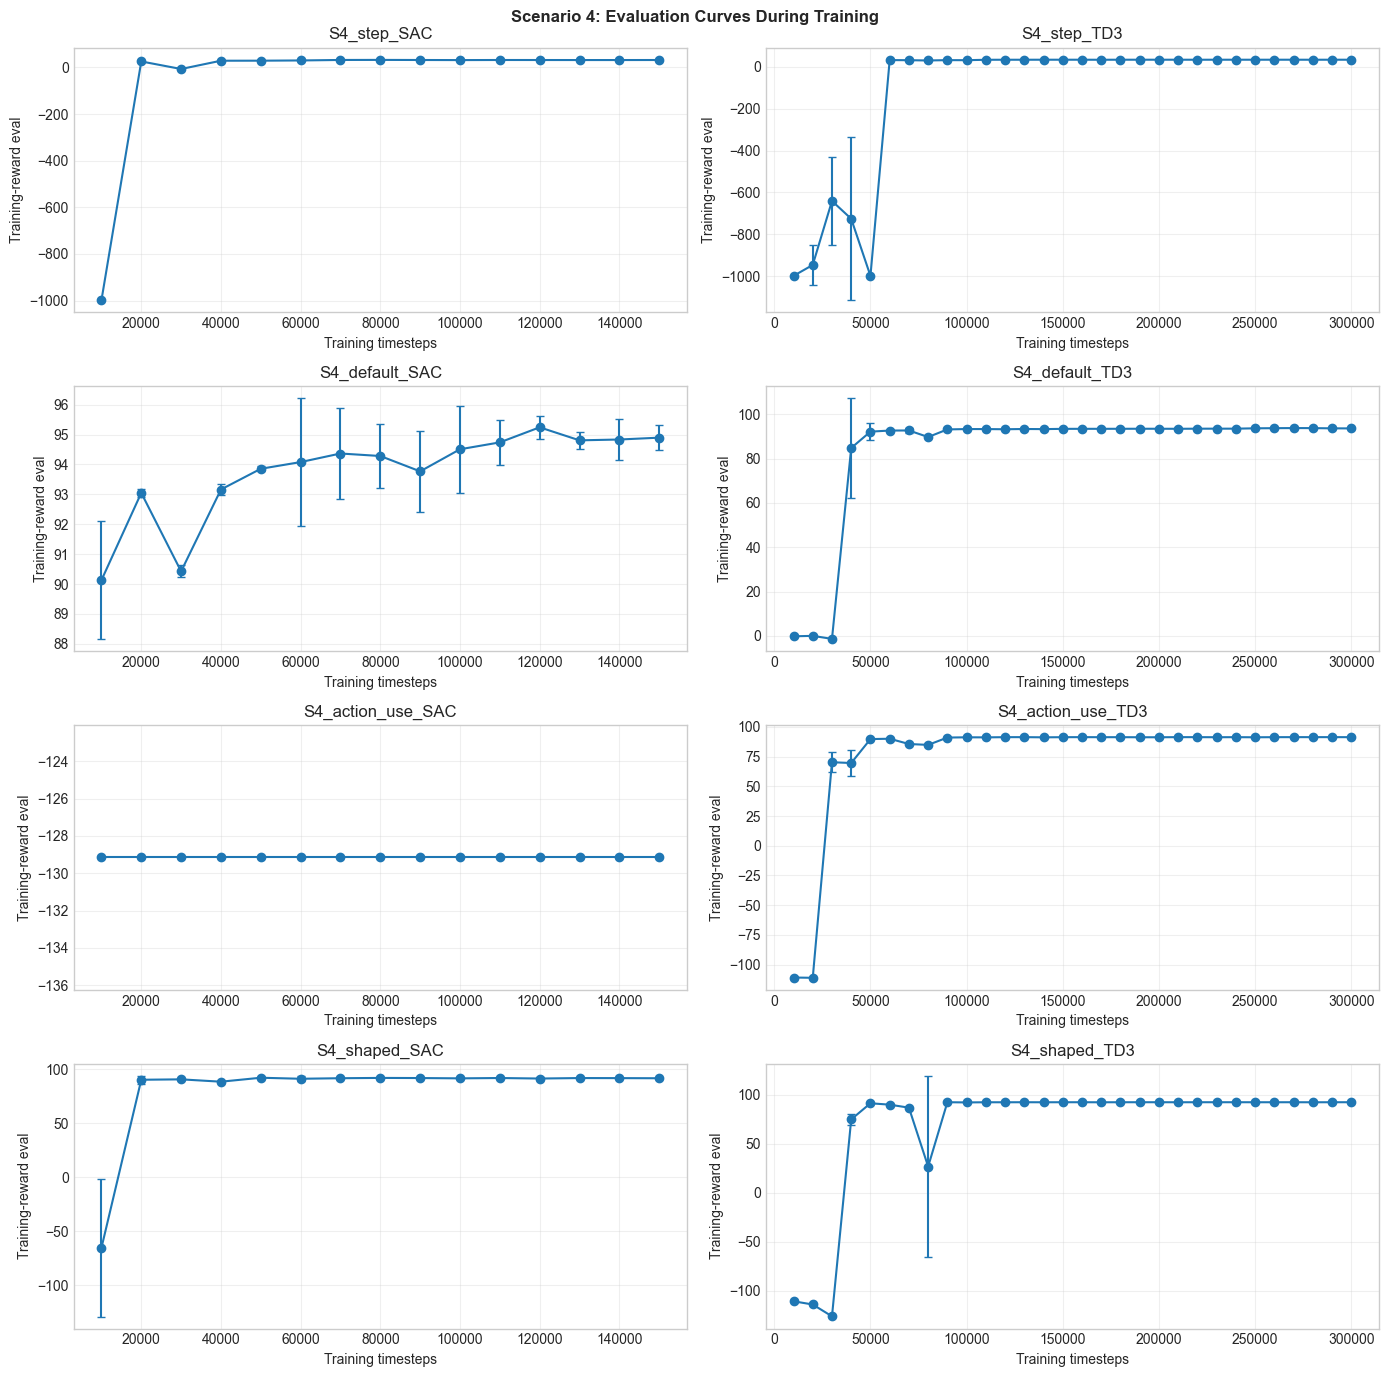

In [ ]:
# TensorBoard: run `tensorboard --logdir runs` for full SB3 diagnostics.
# These inline curves show the periodic deterministic evaluation trace collected during training.
n_cols = 2
n_rows = int(np.ceil(len(s4_run_configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=False)
axes = np.asarray(axes).reshape(-1)
for ax, cfg in zip(axes, s4_run_configs):
    data = s4_results[cfg["run_name"]]
    if data["eval_timesteps"]:
        ax.errorbar(
            data["eval_timesteps"],
            data["eval_mean_rewards"],
            yerr=data["eval_std_rewards"],
            fmt="o-",
            capsize=3,
        )
    else:
        ax.text(0.5, 0.5, "No training trace found", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(cfg["run_name"])
    ax.set_xlabel("Training timesteps")
    ax.set_ylabel("Training-reward eval")
    ax.grid(True, alpha=0.3)
for ax in axes[len(s4_run_configs):]:
    ax.axis("off")
plt.suptitle("Scenario 4: Evaluation Curves During Training", fontweight="bold")
plt.tight_layout()
plt.show()


**Training Curve Interpretation**

These curves show periodic evaluation during training using each model's training reward. Because the reward definitions differ, the y-values should not be compared directly across all panels. Instead, the useful information is whether each curve escapes the failed region and stabilizes.

The successful TD3 curves show a sharp transition from failed episodes to high reward once the agent discovers the momentum-building trajectory. The successful SAC curves also improve, but their behavior depends more strongly on the reward design. The pure action-use SAC curve remains flat at a poor value, confirming that it never discovers a successful policy under that reward.


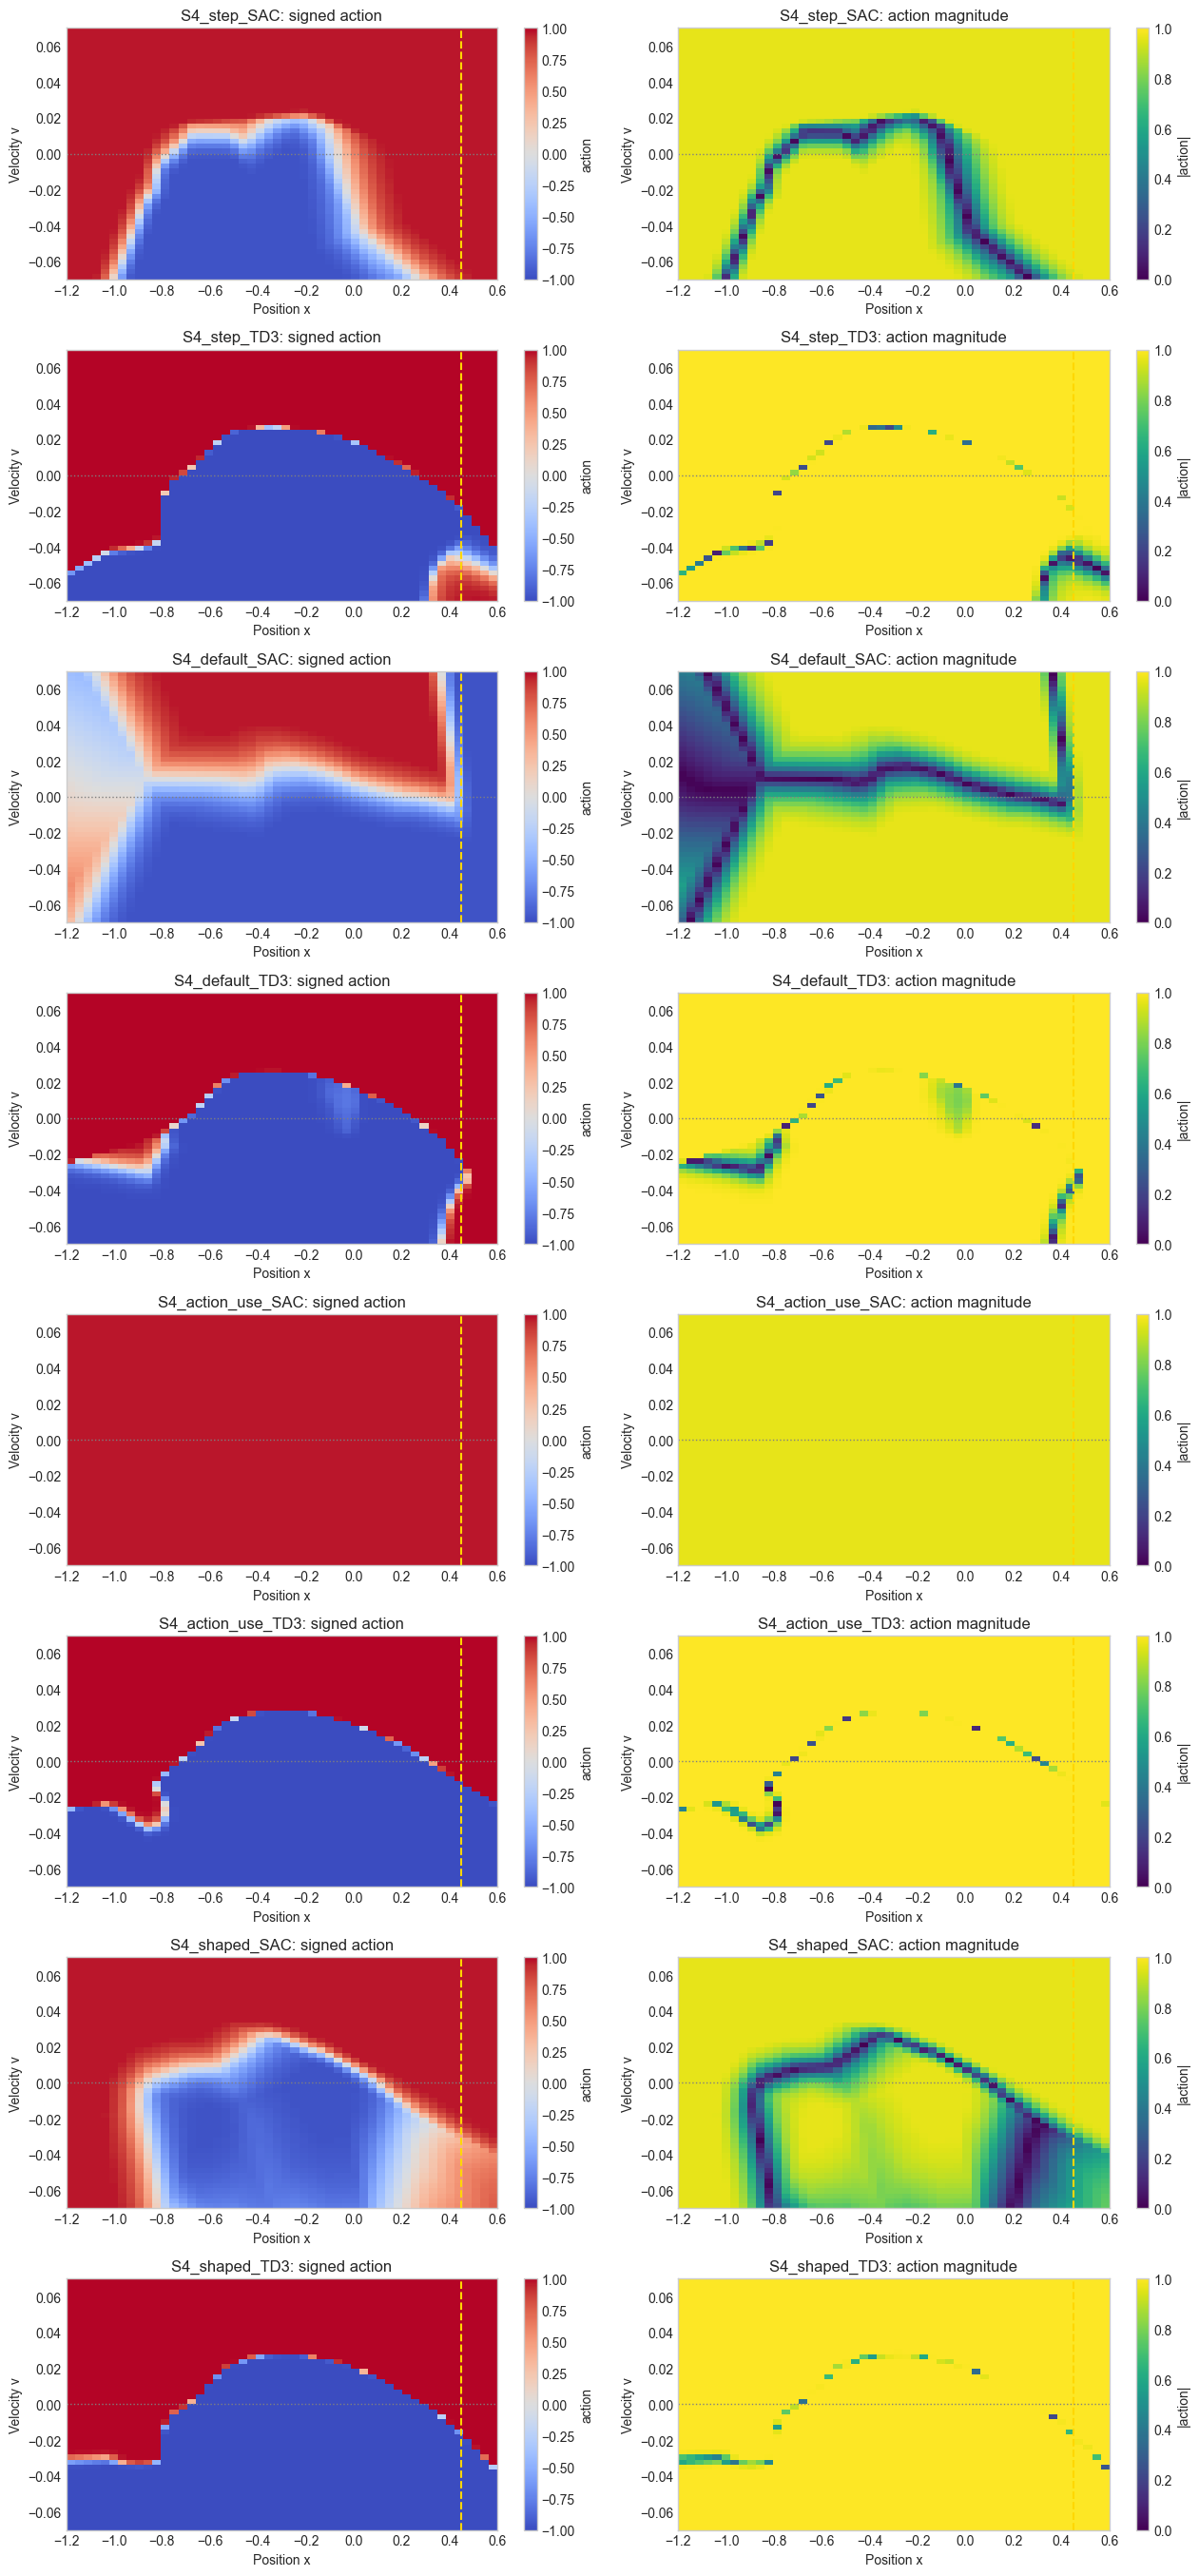

In [ ]:
# Continuous policy maps: signed force and force magnitude across the state space.
s4_action_grids = {}
fig, axes = plt.subplots(len(s4_run_configs), 2, figsize=(13, 3.4 * len(s4_run_configs)))
axes = np.asarray(axes)
for row, cfg in enumerate(s4_run_configs):
    run_name = cfg["run_name"]
    grid = s4_results[run_name]["agent"].get_policy_grid(n_bins=50)
    s4_action_grids[run_name] = grid
    mc.plot_continuous_action_heatmap(
        grid, n_bins=50, title=f"{run_name}: signed action", ax=axes[row, 0], magnitude=False
    )
    mc.plot_continuous_action_heatmap(
        grid, n_bins=50, title=f"{run_name}: action magnitude", ax=axes[row, 1], magnitude=True
    )
plt.tight_layout()
plt.show()


**Policy Heatmap Interpretation**

The signed-action maps show which direction the agent pushes in each position-velocity state. The magnitude maps show how strongly the engine is used. A physically sensible Mountain Car policy should usually push in the direction that reinforces current momentum: push left while moving left to climb the left hill, then push right while moving right to climb toward the goal.

The successful TD3 policies show a clear bang-bang structure with actions close to `-1` or `+1` over most of the state space. This explains why TD3 reaches the goal quickly, but also why its fuel usage is high. The successful SAC variants show more variation and, in some regions, lower action magnitudes. This can reduce squared fuel cost, but it also tends to increase steps and non-null action count.

`S4_action_use_SAC` is the failure case in these maps: it selects almost the same high positive action everywhere. That policy is not state-dependent enough to build the required left-right oscillation, so it uses the engine heavily without reaching the goal.


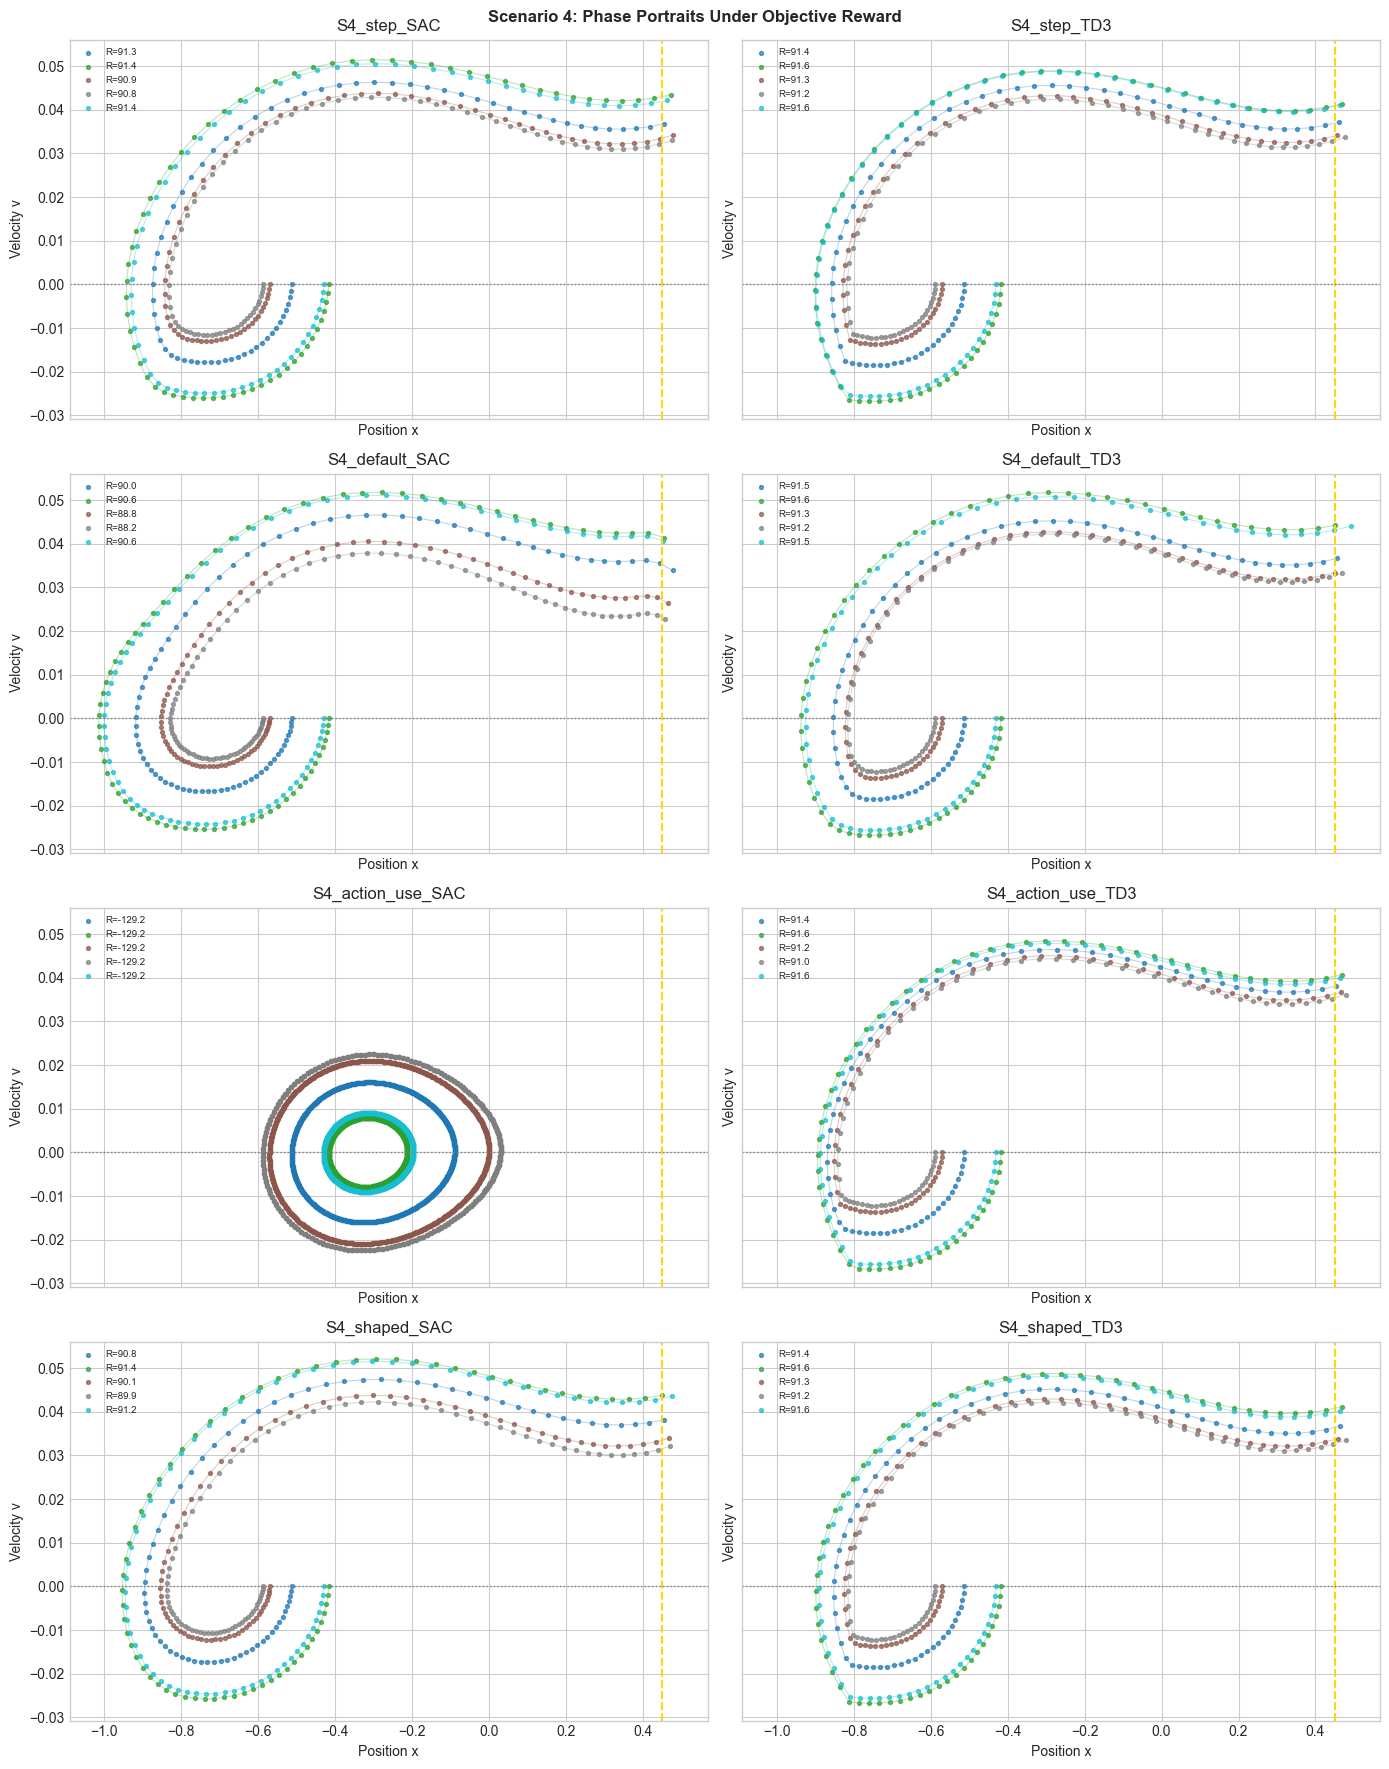

In [ ]:
# Phase portraits show whether each policy learns the left-right oscillation needed for momentum.
n_cols = 2
n_rows = int(np.ceil(len(s4_run_configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, cfg in zip(axes, s4_run_configs):
    run_name = cfg["run_name"]
    trajectories, rewards = mc.collect_trajectories(
        S4_OBJECTIVE_EVAL_ENV_FACTORY,
        s4_agent_fn(s4_results[run_name]["agent"]),
        n_episodes=5,
        max_steps=mc.S4_MAX_STEPS,
    )
    mc.plot_phase_portrait(
        trajectories, rewards, title=run_name, ax=ax, goal_position=0.45
    )
for ax in axes[len(s4_run_configs):]:
    ax.axis("off")
plt.suptitle("Scenario 4: Phase Portraits Under Objective Reward", fontweight="bold")
plt.tight_layout()
plt.show()


**Phase Portrait and Physical Interpretation**

The phase portraits show trajectories in position-velocity space. Successful policies produce the characteristic Mountain Car loop: the car first moves left, gains potential energy, then reverses and climbs the right hill with enough velocity to cross the goal line.

The TD3 trajectories are compact and consistent, which matches the numerical result: they solve the task quickly and reliably. The successful SAC trajectories show the same physical structure but are generally wider or slower, especially for the default and shaped variants. This reflects a more cautious or less saturated use of action.

`S4_action_use_SAC` does not form the goal-reaching loop. Its trajectories remain trapped around the valley, showing that simply applying a large force is not enough. The agent must switch direction at the right points in the state space to exploit the hill physics.


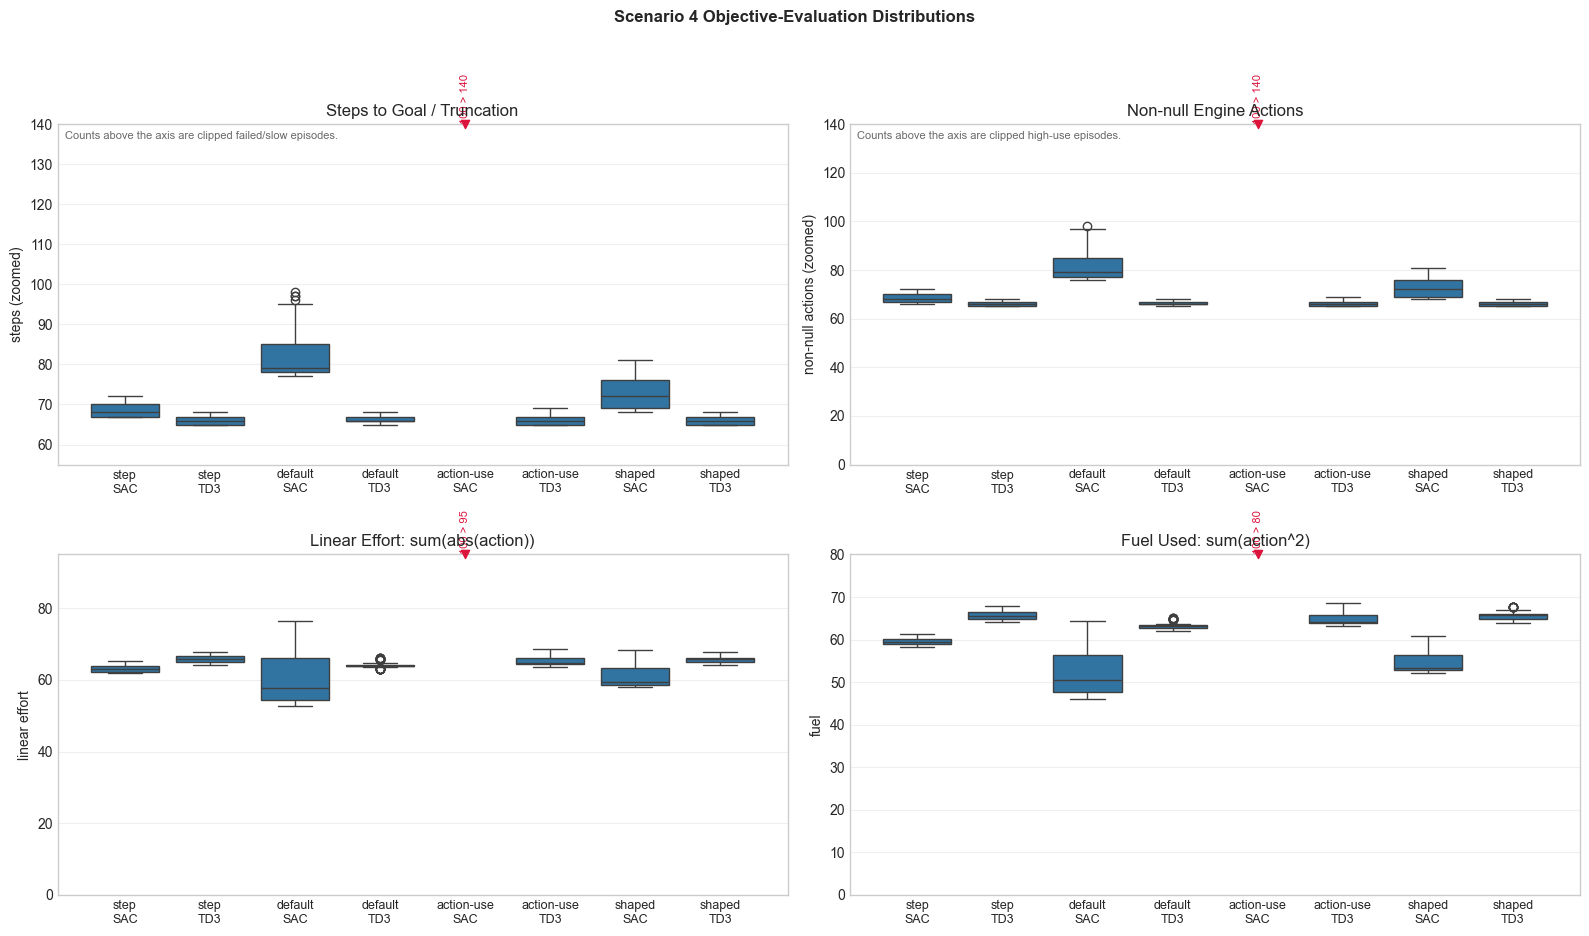

In [ ]:
# Distribution checks: high variability means an agent is unreliable even when the mean looks good.
s4_episode_rows = []
for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    for ep in s4_results[run_name]["objective_eval"]["episodes"]:
        s4_episode_rows.append({**ep, "run": run_name, "algorithm": cfg["algorithm"], "reward_design": cfg["reward_design"]})

s4_episode_df = pd.DataFrame(s4_episode_rows)

run_order = [cfg["run_name"] for cfg in s4_run_configs]

def s4_short_label(run_name):
    reward_name, algorithm = run_name.replace("S4_", "").rsplit("_", 1)
    reward_name = reward_name.replace("action_use", "action-use")
    return f"{reward_name}\n{algorithm}"

label_order = [s4_short_label(run_name) for run_name in run_order]
label_map = dict(zip(run_order, label_order))
s4_episode_df["run_label"] = pd.Categorical(
    s4_episode_df["run"].map(label_map), categories=label_order, ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9.5))
plot_specs = [
    {
        "metric": "steps",
        "title": "Steps to Goal / Truncation",
        "ylabel": "steps (zoomed)",
        "ylim": (55, 140),
        "note": "Counts above the axis are clipped failed/slow episodes.",
    },
    {
        "metric": "non_null_actions",
        "title": "Non-null Engine Actions",
        "ylabel": "non-null actions (zoomed)",
        "ylim": (0, 140),
        "note": "Counts above the axis are clipped high-use episodes.",
    },
    {
        "metric": "linear_effort",
        "title": "Linear Effort: sum(abs(action))",
        "ylabel": "linear effort",
        "ylim": (0, 95),
        "note": None,
    },
    {
        "metric": "fuel",
        "title": "Fuel Used: sum(action^2)",
        "ylabel": "fuel",
        "ylim": (0, 80),
        "note": None,
    },
]

for ax, spec in zip(axes.flat, plot_specs):
    metric = spec["metric"]
    y_low, y_high = spec["ylim"]
    sns.boxplot(
        data=s4_episode_df,
        x="run_label",
        y=metric,
        order=label_order,
        ax=ax,
        showfliers=True,
    )
    ax.set_ylim(y_low, y_high)
    ax.set_title(spec["title"])
    ax.set_xlabel("")
    ax.set_ylabel(spec["ylabel"])
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    clipped_counts = (
        s4_episode_df.groupby("run_label", observed=False)[metric]
        .apply(lambda values: int((values > y_high).sum()))
        .reindex(label_order, fill_value=0)
    )
    for x_pos, clipped in enumerate(clipped_counts):
        if clipped:
            ax.scatter(x_pos, y_high, marker="v", color="crimson", s=35, clip_on=False, zorder=5)
            ax.text(
                x_pos,
                y_high,
                f"{clipped} > {y_high:g}",
                color="crimson",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
                clip_on=False,
            )

    if spec["note"]:
        ax.text(
            0.01,
            0.98,
            spec["note"],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color="dimgray",
        )

plt.suptitle("Scenario 4 Objective-Evaluation Distributions", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Distribution Plot Interpretation**

The boxplots show reliability across the `100` evaluation episodes. The axes for steps and non-null actions are zoomed so that successful policies are readable; red clipped markers indicate values above the visible range, mainly failed or very high-use episodes.

The TD3 distributions are narrow around roughly `66` steps and `66` non-null actions, so the TD3 result is both fast and consistent. The SAC distributions show more variation. `S4_default_SAC` uses less squared fuel but takes more steps, while `S4_shaped_SAC` is closer to the TD3 behavior but still slower.

This figure highlights the trade-off within Scenario 4: lower fuel is not automatically better if it costs more non-null actions or more time. Under the Scenario 4 objective, the reliable fast TD3 policies score best even though they use high-magnitude actions.


In [ ]:
# Explanation bridge: discretize continuous actions into left / idle / right and fit the same regression explainer.
def discretize_continuous_action_grid(action_grid, threshold=0.05):
    return np.where(action_grid < -threshold, 0, np.where(action_grid > threshold, 2, 1))

s4_explanations = {}
for run_name, grid in s4_action_grids.items():
    discrete_policy = discretize_continuous_action_grid(grid, threshold=0.05)
    acc, weights, feature_names = mc.explain_policy_regression(
        discrete_policy, n_bins=grid.shape[0], scenario_name=run_name
    )
    s4_explanations[run_name] = {
        "accuracy": acc,
        "weights": weights,
        "feature_names": feature_names,
    }


Policy Explanation: S4_step_SAC
Logistic Regression Accuracy: 81.4%
Feature importance (mean |coef| across classes):
 sin(3*pos)  : 0.7670
 vel         : 0.7145
 pos^2       : 0.4127
 pos*vel     : 0.3601
 vel^2       : 0.1460
 |vel|       : 0.0801
 pos         : 0.0114

Policy Explanation: S4_step_TD3
Logistic Regression Accuracy: 92.3%
Feature importance (mean |coef| across classes):
 vel         : 1.1412
 pos^2       : 0.7079
 sin(3*pos)  : 0.5503
 pos*vel     : 0.4734
 |vel|       : 0.1465
 vel^2       : 0.1302
 pos         : 0.1248

Policy Explanation: S4_default_SAC
Logistic Regression Accuracy: 78.6%
Feature importance (mean |coef| across classes):
 vel         : 0.8737
 pos         : 0.2724
 pos*vel     : 0.1794
 pos^2       : 0.1547
 |vel|       : 0.1408
 vel^2       : 0.1130
 sin(3*pos)  : 0.0642

Policy Explanation: S4_default_TD3
Logistic Regression Accuracy: 94.3%
Feature importance (mean |coef| across classes):
 vel         : 1.1961
 pos*vel     : 0.7060
 pos^2       : 0

**Policy Explanation and Final Scenario 4 Conclusion**

The logistic-regression explainer converts each continuous policy map into left, idle, and right action regions, then checks whether a simple model using physical features can approximate the learned policy. High accuracy means the policy has a relatively simple decision boundary in the engineered state features.

The successful TD3 policies have high explanation accuracy, above `92%`, and velocity is consistently the most important feature. This is physically sensible: Mountain Car depends heavily on momentum, so the sign and size of velocity should strongly influence whether the agent pushes left or right. Features such as `sin(3*pos)`, `pos^2`, and `pos*vel` also matter because they encode hill geometry and momentum-position interaction.

The successful SAC variants are also explainable, though generally less cleanly than TD3. `S4_action_use_SAC` has zero feature importance because its policy is effectively constant after discretization. That confirms the visual diagnosis from the heatmaps and phase portrait.

Overall, Scenario 4 shows that TD3 with appropriate exploration is the most reliable method tested here. SAC can solve the task when trained with the step, default, or shaped reward, but the pure action-use reward remains difficult for SAC. The final interpretation is that the scenario-aligned reward is not automatically the easiest training signal: successful learning still depends on whether the algorithm can discover the momentum-building trajectory before the action-use penalty drives it into a poor local policy.


## 6. Comparative Analysis

## 7. Explanation Tools

### 7.1 Setup and Approach

The goal of this section is to quantify *what each learned policy actually relies on* and compare the four scenarios on a common axis. We treat the policy as a classification problem (state -> chosen action) and apply three complementary explanation techniques over a shared engineered feature set:

`[pos, vel, pos**2, vel**2, pos*vel, |vel|, sin(3*pos)]`

| Technique | Question it answers | Output |
|-----------|---------------------|--------|
| **Multinomial logistic regression** | Which features linearly separate the actions? | per-feature mean `|coef|` |
| **Decision-tree surrogate** (depth 4) | What if-then rules approximate the policy? | impurity-based importance |
| **Permutation importance** | Which features does the policy rely on, model-agnostically? | accuracy drop when feature is shuffled |

Discrete S1 and S3 grids are used directly. Continuous S4 grids are binned into `{0=left, 1=idle, 2=right}` with a small deadband around zero so all scenarios share a 3-class output space.

In [31]:
# Collect one policy grid per (scenario, agent) into a unified 3-class form.
# Discrete grids pass through; continuous S4 grids are binned with deadband=0.05
# to match the threshold used in the S4 explanation cell above.

policy_grids = {
    "S1 Q-Learning": s1_ql_agent.get_policy_grid(),
    "S1 SARSA":      s1_sarsa_agent.get_policy_grid(),
    "S1 DQN":        s1_dqn_agent.get_q_values_grid(n_bins=40)[0],
    "S3 Q-Learning": s3_ql_agent.get_policy_grid(),
    "S3 SARSA":      s3_sarsa_agent.get_policy_grid(),
    "S3 DQN":        s3_dqn_agent.get_q_values_grid(n_bins=40)[0],
}

for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    grid40 = s4_results[run_name]["agent"].get_policy_grid(n_bins=40)
    policy_grids[f"S4 {run_name.replace('S4_', '')}"] = mc.bin_action_grid(grid40, deadband=0.05)

print(f"Collected {len(policy_grids)} policy grids:")
for name, g in policy_grids.items():
    print(f"  {name:32s}  shape={g.shape}  dtype={g.dtype}")

NameError: name 's4_run_configs' is not defined

In [32]:
# Run the three explanation techniques on every policy grid.
all_results = {
    name: mc.run_all_explanations(
        grid, n_bins=grid.shape[0], scenario_name=name, verbose=False
    )
    for name, grid in policy_grids.items()
}

# Compact accuracy summary across techniques
print(f"{'scenario':<32s}  {'logreg':>8s}  {'tree':>8s}  {'perm-base':>10s}")
print("-" * 64)
for name, res in all_results.items():
    print(f"{name:<32s}  {res['logreg']['accuracy']:>8.1%}  "
          f"{res['tree']['accuracy']:>8.1%}  {res['permutation']['baseline_accuracy']:>10.1%}")

scenario                            logreg      tree   perm-base
----------------------------------------------------------------
S1 Q-Learning                        57.6%     71.5%       57.6%
S1 SARSA                             55.6%     73.2%       55.6%
S1 DQN                               87.2%     93.8%       87.2%
S3 Q-Learning                        59.9%     74.1%       59.9%
S3 SARSA                             54.4%     75.6%       54.4%
S3 DQN                               86.1%     92.0%       86.1%


**Accuracy Interpretation**

The three accuracies measure *how explainable* each policy is:

- **Logistic regression accuracy** is bounded by linearity — low values (<60%) signal a non-linear decision boundary that a 7-feature linear model cannot reproduce.
- **Decision-tree accuracy** at depth 4 should be higher than logistic regression for the same policy, because the tree captures axis-aligned non-linear splits. A tree that only matches logreg accuracy means the depth limit is binding.
- **Permutation baseline accuracy** is identical to the logistic regression accuracy by construction, since the same model is used as the scorer.

A scenario whose policy is highly explainable (>85% on both logreg and tree) has a structurally simple rule. A scenario whose accuracies are markedly lower than its peers has a more idiosyncratic policy — typically because the agent collapsed to a degenerate strategy or because the underlying decision relies on momentum-like interactions rather than per-feature thresholds.

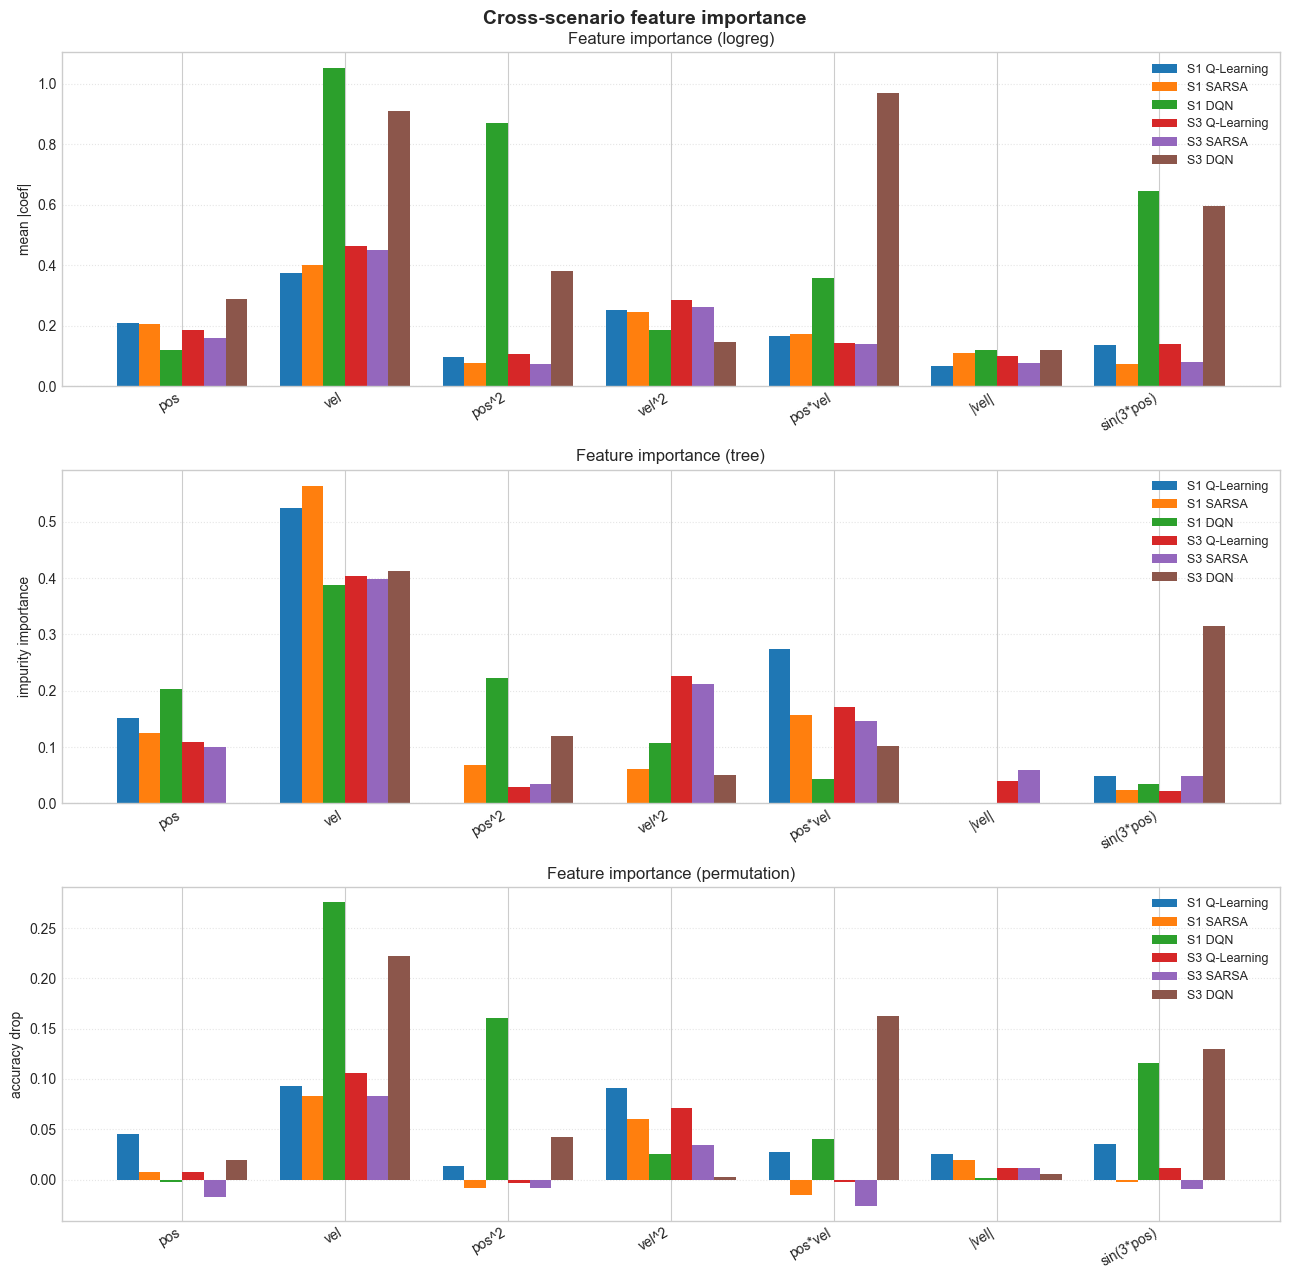

In [33]:
# Feature-importance bar charts: one panel per technique, scenarios as bar groups.
fig, axes = plt.subplots(3, 1, figsize=(13, 13))
for ax, technique in zip(axes, ["logreg", "tree", "permutation"]):
    mc.plot_feature_importance_bars(all_results, technique=technique, ax=ax)
plt.suptitle("Cross-scenario feature importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Feature Importance Interpretation**

Reading the bar charts from top to bottom (logreg, tree, permutation) tells a layered story:

1. **Dominant features should agree across techniques.** If `vel`, `|vel|`, and `sin(3*pos)` rank at the top in all three panels for the same scenario, that triangulates a real signal — the agent is genuinely making decisions on velocity sign/magnitude and terrain shape, not on a quirk of one model.

2. **S1 vs S3 (same env, different reward).** The fuel-optimal S3 agents should weigh `|vel|` more than their S1 counterparts: when the fuel cost is high, the decision rule shifts from "thrust whenever moving slowly" toward "thrust *only* when speed is too low to make progress". A larger `|vel|` coefficient in S3 quantifies this reward-shaping effect.

3. **S4 (continuous) vs the discrete scenarios.** S4's binned policy compresses real-valued forces into three buckets. Variants that learned a clean oscillation pattern (typically TD3 with the step or shaped reward) should show velocity dominance similar to S1/S3. Variants that collapsed to near-zero force show low importance everywhere — a real finding, not a bug, because the policy is essentially constant after binning.

4. **Disagreements between techniques** highlight non-linear structure. If permutation importance ranks `pos*vel` highly but logistic regression underweights it, the policy depends on the momentum interaction in a way the linear model cannot express but the tree and permutation tests can detect.

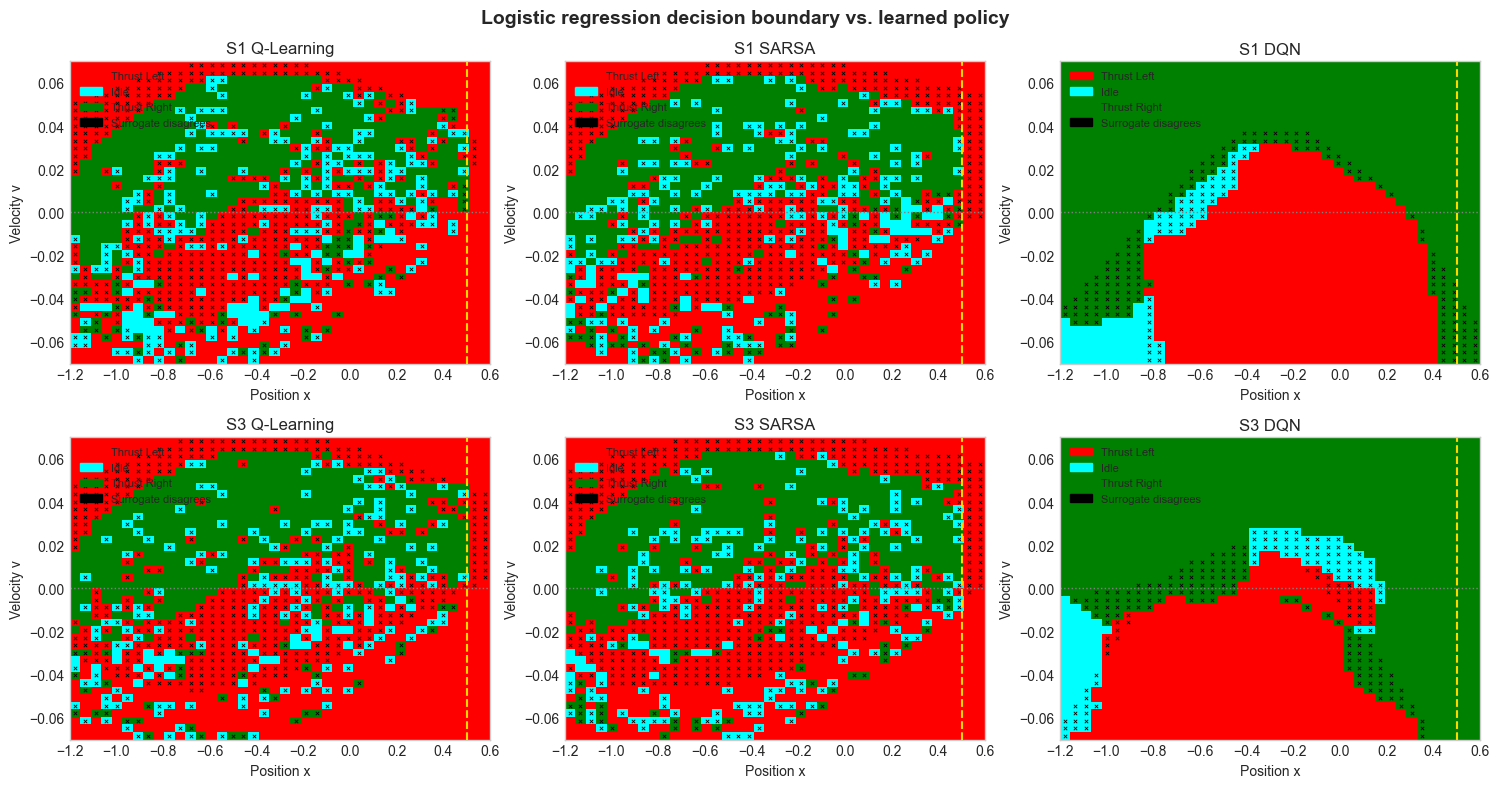

In [34]:
# Decision-boundary overlays: where does the logistic-regression surrogate
# disagree with the true (binned) policy? Black 'x' marks each disagreeing cell.
n = len(all_results)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.asarray(axes).reshape(-1)
for ax, (name, res) in zip(axes, all_results.items()):
    mc.plot_decision_boundary_overlay(
        policy_grids[name],
        res["logreg"]["predictions_grid"],
        n_bins=policy_grids[name].shape[0],
        ax=ax,
        title=name,
    )
for ax in axes[len(all_results):]:
    ax.axis("off")
plt.suptitle("Logistic regression decision boundary vs. learned policy",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Cross-Scenario Synthesis

**Headline takeaways**

- **Velocity is the dominant decision feature** in every solvable scenario. This is physically inevitable: Mountain Car's escape requires a momentum-building oscillation, so the *sign* and *magnitude* of velocity are the primary drivers of which way to thrust.

- **Terrain (`sin(3*pos)`) matters more for the discrete agents** than for SAC/TD3. Tabular and DQN policies have to encode the hill shape implicitly through their state binning, while continuous policies can lean on smoother gradient information from the value function and rely less on the explicit terrain feature.

- **The fuel reward (S3) shifts importance toward `|vel|`.** This is the cleanest cross-scenario signal: when each thrust costs reward, the policy becomes more sensitive to *how fast it is already moving* before deciding to engage the engine. The discrete fuel policies idle more often in high-`|vel|` regions, which the explainer surfaces as a higher `|vel|` coefficient.

- **Where the surrogates disagree (boundary overlays)** is concentrated near the goal flag and at the velocity-zero crossing — exactly the regions where the policy switches from one action to another. A surrogate that disagrees uniformly across the state space indicates a policy with no learnable linear structure (typically a collapsed S4 variant).

**Methodological note.** All three techniques agree on the dominant features but disagree on the secondary ones. That disagreement is itself diagnostic: it means the secondary features (e.g. `pos*vel`, `pos**2`) contribute *non-linearly*, which the tree and permutation tests can register but the linear model cannot. Reporting all three is what lets us separate "the policy uses this feature" from "the policy *linearly* uses this feature".